# <font color="steelblue">220. Introducción a la inferencia estadística</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** En este cuaderno se presentan los cocpetos fundamentales de la inferencia estadística sobre los que profundizaremos en los cuadernos siguientes.

Se definen los conceptos de estimador y estimación, y se presenta la distrbución en el muestreo como la herramienta necesaria apra llevar a cabo cualquier análisis inferencial, donde estamos interesados en generalizar los resultados de nuestra muestra a la población de la que proviene.

Se presentan además los procesos de inferencia habituales: estimación puntual, estimación por intervalos de confianza, y contrastes de hipótesis.


## <font color='steelblue'> Objetivos de aprendizaje

* Comprender la utilidad de la inferencia estadística para extraer conclusiones válidas de nuestros estudios estadísticos.

* Conocer los conceptos involucrados en una análisis inferencial.

* Entender el funcionamiento de la distribución en el muestreo.

* Diferenciar entre los procedimientos de inferencia: estiamción y contraste de hipótesis.


## <font color='steelblue'> Contenidos </font>

1. Introducción
1. Estimador y estimación
1. Distribución en el muestreo
1. Procedmientos de inferencia estadística


## <font color='steelblue'> 1. Introducción

El objetivo principal de la inferencia estadística es estudiar y extraer conclusiones acerca de la población bajo estudio, basándonos en los datos muestrales observados y la distribución de probabilidad de los datos poblacionales.

Lo srazonamientos de la inferencia estadística se basan en preguntar: ¿con qué frecuencia daría este método una respuesta correcta si lo utilizara muchas veces?

La inferencia estadística es posible porque no tiene sentido imaginar la obtención de los mismos datos de forma repetida y en las mismas circunstancias.
Al utilizar el azar para escoger a los individuos de una muestra, las leyes de la probabilidad permiten responder a la pregunta anterior.
Estudiamos aquí la obtención de la distribución en el muestreo de diferentes estadísticos necesarios en los procesos de inferencia más habituales.Para ello haremos uso del Teorema Central del Límite, estudiado en el cuaderno anterior.

Los procedimientos de inferencia estadística más básicos se basan en la estimación puntual, intervalos de confianza y contrastes de hipótesis cuyos fundamentos presentamos en este cuaderno.

Para comenzar cargamos los módulos que son necesarios para el desarrollo del cuaderno.

In [ ]:
# Cargamos módulos de análisis numérico
import numpy as np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = 'retina'

from scipy import stats

## <font color='steelblue'> 2. Estimador y estimación

Muchas veces intentamos deducir la media poblacional a partir de la de una muestra, y para esto deberemos tener una muestra suficientemente grande o representativa de la población. La palabra *población* corresponde a los datos de toda una población, pero esto es imposible o muy difícil, por lo que solo vemos una pequeña muestra (relativamente hablando) en un momento dado.

Dada una población y una característica observable o variable aleatoria de interés $X$, dependiente de un parámetro poblacional $\theta$,  se define:

* Un **estimador** del parámetro poblacional, como una función matemática que representa la cantidad de información proporcionada por cada uno de los sujetos observables en una muestra de tamaño n.
* Una **estimación** del parámetro de interés, como el valor numérico obtenido al sustituir los datos observados en la fórmula del estimador propuesto.

De esta forma, el estimador es general para cualquier población, y por tanto, es una nueva variable aleatoria, mientras que la estimación es un valor concreto del estimador que depende de la muestra observada.

**Ejemplo**. Imaginemos que estamos interesados en conocer la altura media de los españoles que es una valor desconocido y que denotamos por $\mu$. Para obtener dicha media (parámetro poblacional) es necesario conocer el valor de la altura para cada uno de los españoles (variable aleatoria, $X$), pero esto resulta imposible ya que no podemos medirlos a todos en un tiempo prudencial.

Por ello la forma habitual de proceder es tomar una muestra representativa de $n$ sujetos, sobre los que debemos medir su altura que denotamos por $X_1, X_2,..., X_n$.

Definimos entonces el estimador media muestral ($\bar{x}$) como

$$\bar{X} = \frac{\sum_{i=1}^n X_i}{n}$$

que nos permite calcular la media muestral en cualquier situación, independientemente de los sujetos utilizados en la muestra, el tamaño, y los valores observados.

Una vez medimos las alturas de los $n$ sujetos que denotamos por $x_1, x_2,...,x_n$ podemos obtener una estimación de la media muestral cuyo valor si varía en función de los sujetos elegidos en la muestra

El valor de la media obtenida (media muestral) para el conjunto de los n sujetos seleccionados es una estimación de la media poblacional, que varía si cambiamos el grupo de sujetos.

Por tanto el estimador de un parámetro poblacional es fijo y depende de las propias características de lo que estemos midiendo (medias o proporciones), mientras que la estimación varía en función del grupo de sujetos considerado, ya que obtendremos valores distintos de la media muestral, y por lo tanto la media muestral es una nueva varaible aleatoria. A esta acción de deducir una medida se le conoce como **inferencia**.


Los estimadores habituales considerados son las versiones muestrales de los parámetros poblacionales de interés. Por ejemplo:

* la media muestral es el estimador de la media poblacional
* la varianza muestral es el estimador de la varianza poblacional
* la proporción muestral es el estimador de la proporción poblacional

y así con muchos otros como veremos en el resto de este cuaderno.

## <font color='steelblue'> 3. Distribución en el muestreo

Para que los procesos de inferencia sean de utilidad nos deberemos asegurar que la estimación obtenida no cambia “mucho” entre dos muestras de sujetos diferentes. Los razonamientos de la inferencia estadística se basan en preguntar ¿con qué frecuencia la información obtenida a partir de una muestra representa y describe de forma lo más precisa posible la población de la que se extrae dicha muestra?

Dado que resulta muy difícil, hablando en términos probabilísticos, obtener dos muestras completamente iguales de una misma población, es necesario establecer procedimientos que permitan responder a la pregunta anterior. Se define la distribución en el muestreo de un estimador como la distribución de probabilidad asociada al conjunto de valores posibles que dicho estimador puede tomar para cada una de las posibles muestras de igual tamaño en la misma población. Básicamente lo que tratamos de establecer es la distribución de probabilidad que nos indica como de compatible es la muestra considerado con respecto a los verdaderos valores poblacionales. Para ello hay que tener en cuenta dos conceptos fundamentales como son el sesgo y la variabilidad.

El sesgo aparece cuando el método para seleccionar el conjunto de sujetos muestras es erróneo. Por ejemplo, si queremos estudiar la altura media de los hombres, y en la muestra sólo observamos sujetos que miden menos de 165 cm, nuestro estimador de la media de la altura estará sesgado hacia los sujetos más pequeños de la población.
La variabilidad mide como cambia el valor de la estimación de una muestra a otra. Cuando el tamaño de la muestra aumenta la precisión que tenemos a la hora de estimar el parámetro de interés crece, ya que cuanta más información tenemos más seguridad tendremos sobre el verdadero valor del parámetro de interés.

La distribución en el muestreo del parámetro de interés en una población se puede aproximar en los casos más sencillos (medias y proporciones) mediante el teorema central del límite, obteniendo distribuciones de tipo Normal que nos permiten con cierta facilidad calcular todas las probabilidades necesarias en el proceso inferencial.

A continuación mostramos las formulaciones teóricas de las distribuciones en el muestreo más habituales, y veremos la aproximación obtenida mediante una análisis numérico.

### <font color='steelblue'> Media muestral con varianza poblacional conocida

En el cuaderno anterior utilizando el Teorema Central del Límite, ya pudimos ver que si tenemos una varaible aleatoria que se distribuye según

$$X \sim N(\mu, \sigma)$$

con $\sigma$ conocida, entonces la variable aleatoria media muestral se distribuye según

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right),$$

es decir, ambas distribuciones comparten la misima media, pero distinta desviación típica, ya que cuanta más información es recogida (aumentamos n) más se debe parecer el valor de la media muestral al valor de la media poblacional.


Veamos el siguiente experimento:

1. Generamos una población de tamaño 1000000 a partir de una distribución normal con media 175 y desviación típica conocida de 10. (El experimento trata de reflejar la altura media de los españoles)

2. Extraemos m muestras de tamaño n y calculamos la media muestral en cada una de ellas.

3. Representamos mediante un histograma los valores obtenidos de medias muestrales, comparamos la media pobalcional (amarillo) con la media muestral (rojo).


Antes de comenzar obtenemos los valores pobalcionales y los representamos gráficamente.

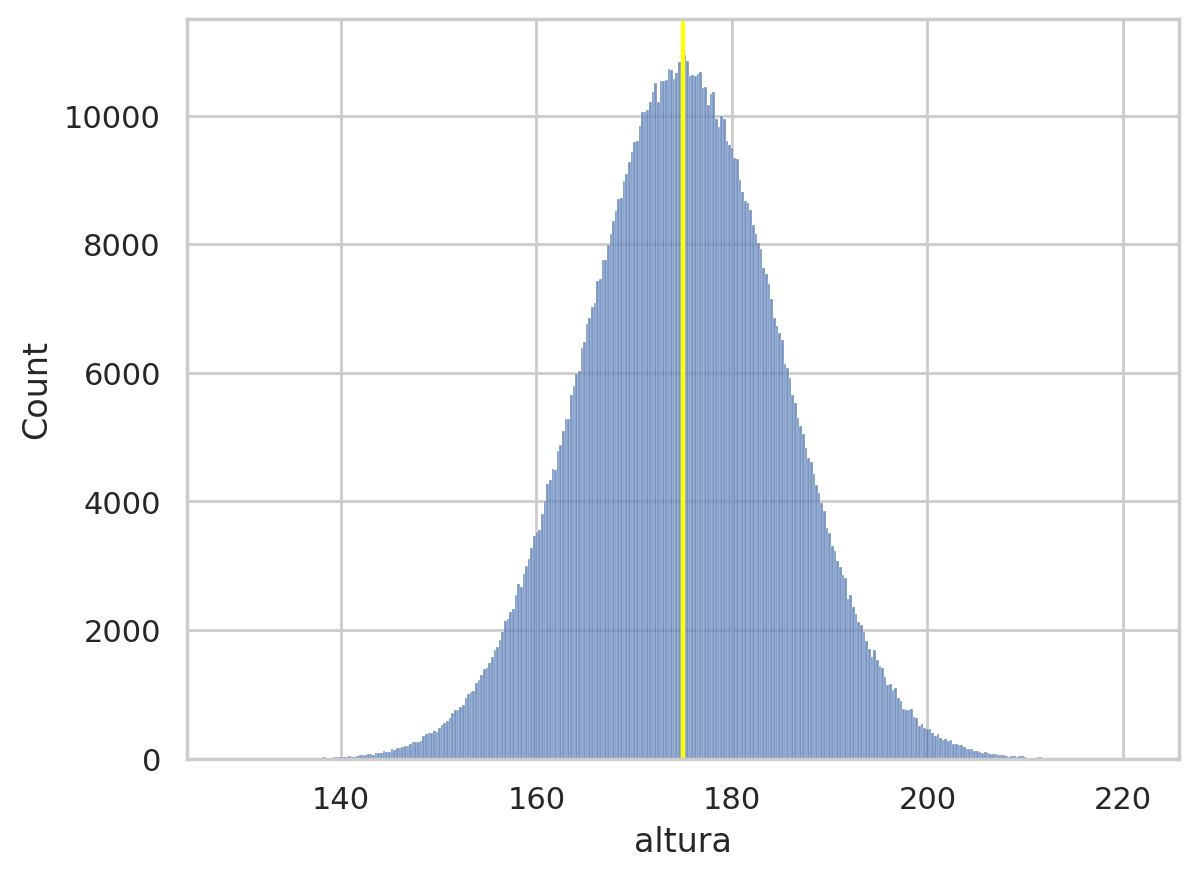

In [ ]:
# Generamos los valores de la población
population = pd.DataFrame({"altura": stats.norm.rvs(size=1000000, loc=175, scale=10)})
# Representamos gráficamente los valores obtenidos
g=sns.histplot(data=population, x="altura")
g.axvline(175, color ="yellow"); # media poblacional

Para llevar a cabo el experimento varíaremos el número de muestras en los valores 10, 20, 30, 40, 50, 100, 150, 200, 300 y fijamos el tamaño muestral en 50.

Veamos las diferentes repeticiones

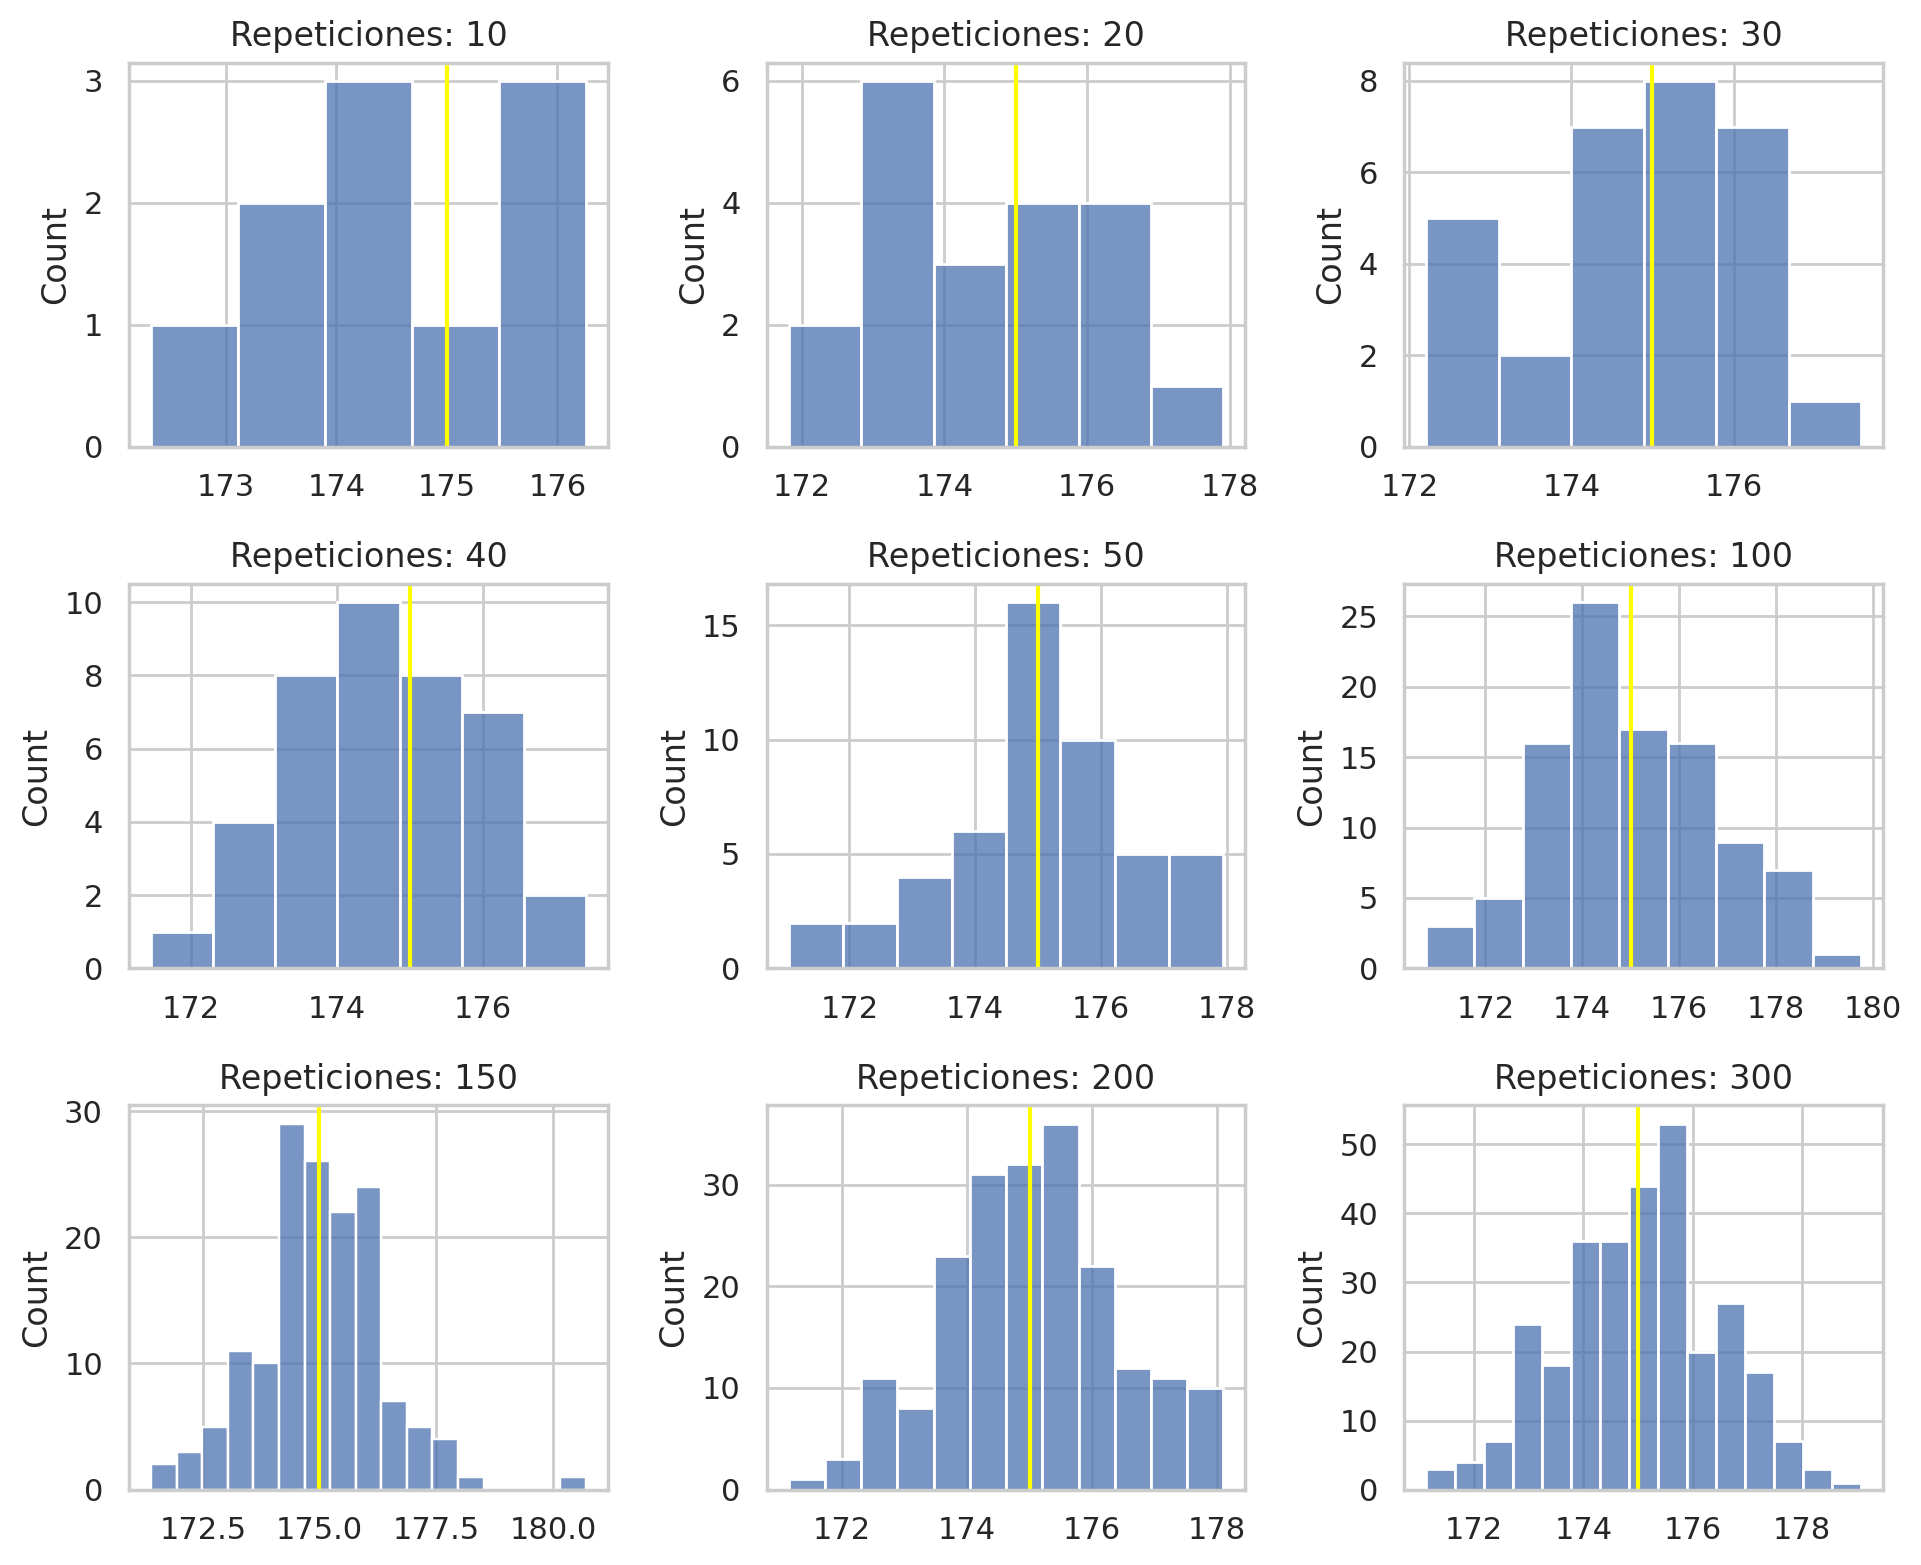

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 50
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  medias = []
  rep = 0
  while rep < repeticiones[i]:
    muestra = population.altura.sample(n, replace=True)
    medias.append(muestra.mean())
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=medias)
  g.set_title(f"Repeticiones: {repeticiones[i]}")
  g.axvline(175, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

Como podemos ver al aumentar el número de repticiones la forma de la distribción de la media muestral se va apreciendo cada vez más  a la de un Normal centrada en la media poblacional. Veasmo que ocurre si aumentamos el tamaño muestral de cada repetición a 100.

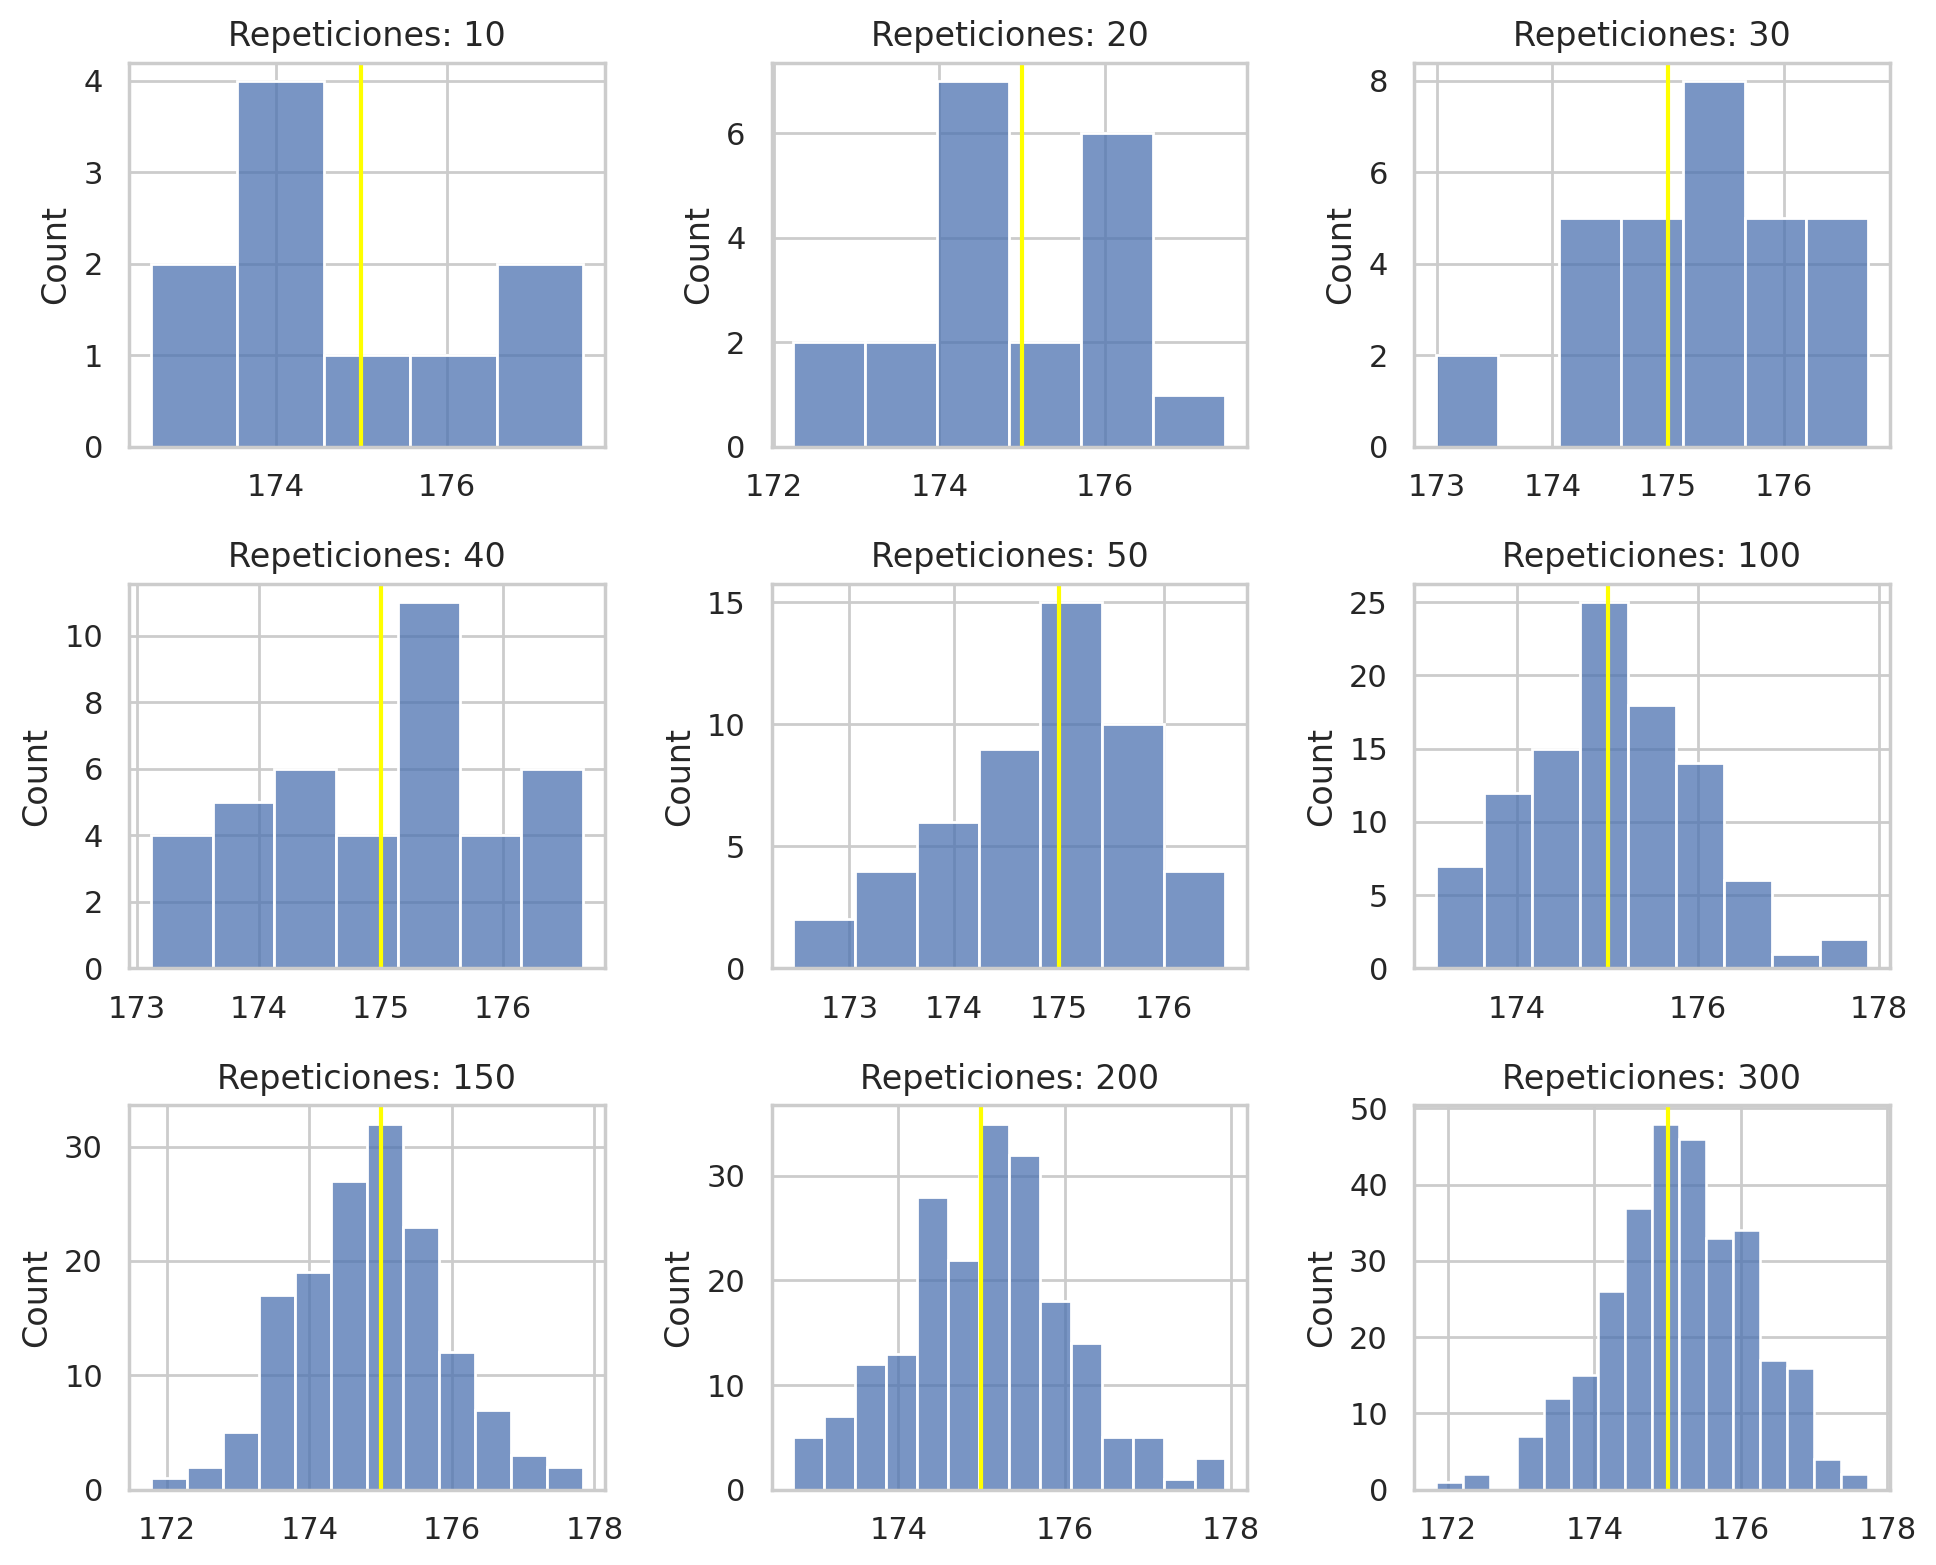

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  medias = []
  rep = 0
  while rep < repeticiones[i]:
    muestra = population.altura.sample(n, replace=True)
    medias.append(muestra.mean())
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=medias)
  g.set_title(f"Repeticiones: {repeticiones[i]}")
  g.axvline(175, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

El comportamiento es mucho mejor en cuanto el número de repeticiones supera las 30. El problema práctico que tnemos en que en realidad nosotros únicamente obtenedremos una muestra y deberemos jugar con us tamaño para tratar de inferir adecuadamente sobre la media de la población.

### <font color='steelblue'> Media muestral con varianza poblacional desconocida

En la práctica habitual es muy díficil que conozcamos con exactitud cualquiera de los parámetros que caracterizan una población. En el caso de la distribució Normal si la varianza es desconocida también deberemos inferir sobre ella para poder aprender de forma correcta sobre el comortamiento de la población.

La varianza muestral o la desviación típica muestral no serán iguales a las poblacionales, pero al dividir la desviación típica entre la raíz cuadrada del tamaño muestral para la distribución normal de la media, el error se ve reducido considerablemente y la aproximación funciona. En este caso, cabe diferenciar que a la desviación típica poblacional la representaremos como $\sigma$ y a la muestral como $s$, y las varianzas igual pero elevado al cuadrado. Tenemos así que: $\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}} \simeq \frac{s}{\sqrt{n}}$.

Hay que tener cuidado ahora porque no sabemos el valor de ninguna medida de dispersión poblacional, por lo que no podremos aplicar el *Teorema Central del Límite* como tal. Por tanto, ahora nos ayudaremos de una nueva distribución, la **distribución t de Student**. Esta describe la distancia que existe entra la media muestral y la media real (poblacional) cuando no tenemos el valor de la desviación típica ni de la varianza poblacional. Tiene también como parámetros la media ($\mu$) y la desviación típica ($\sigma$), y además tiene los **grados de libertad** (gl). Tendremos $\mu = \bar{x}$, $\sigma = \frac{s}{\sqrt{n}}$ y $gl = n-1$. Con todo esto, tenemos que: $\bar{x} - \mu \sim T_{n-1}(0, \frac{s}{\sqrt{n}})$.

A continuación, vamos a representar en un gráfico la curva de una $Normal(0, 1)$ y las curvas correspondientes a una $T~de~Student$, con diferentes grados de libertad. La distribución *t de Student* se realiza con la función `t` del módulo `stats`. En el argumento `df` indicaremos los grados de libertad.

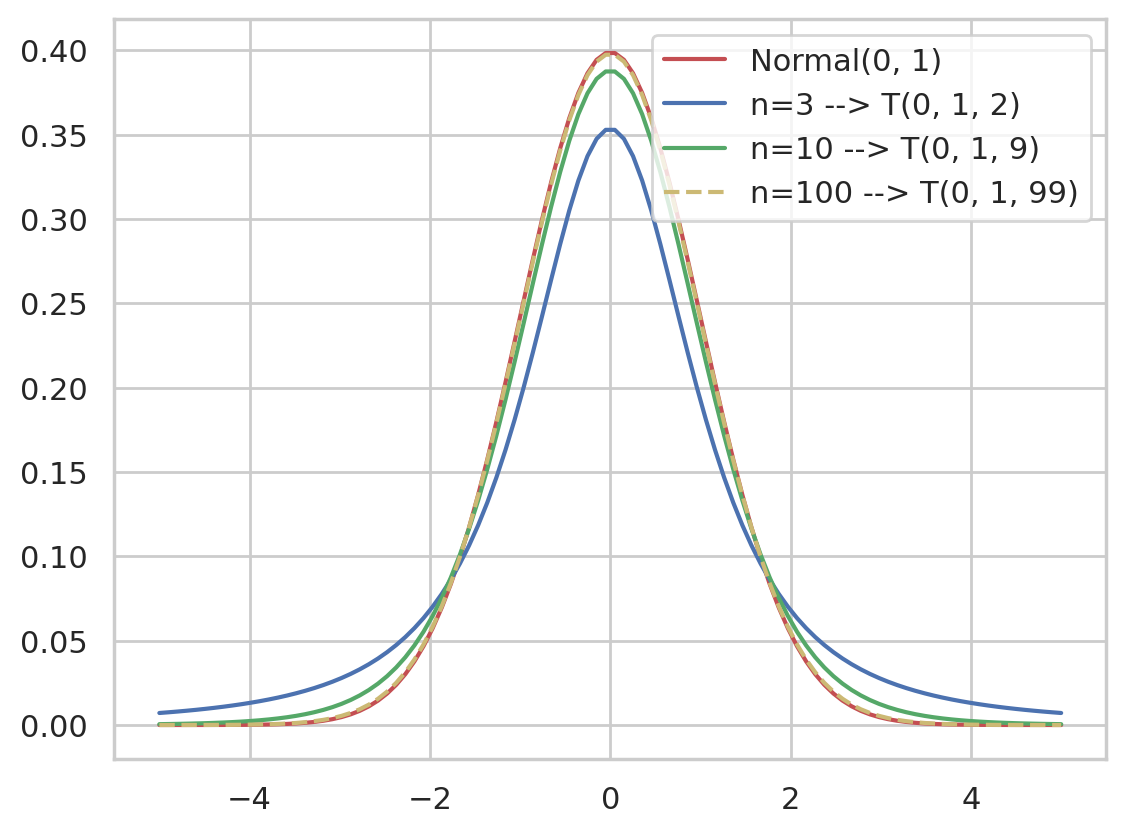

In [ ]:
# Array con 100 valores que van desde -5 hasta 5
x = np.linspace(-5, 5, 100)

# Función de densidad del array x para una Normal(0, 1)
y_normal = stats.norm.pdf(x)
# Representamos los valores de x y su densidad correspondiente para una Normal(0, 1)
plt.plot(x, y_normal, color='r', label="Normal(0, 1)")

# Función de densidad del array x para una T de Student(0, 1, 2), con n=3
y_student_3 = stats.t.pdf(x, df=3-1)
# Representamos los valores de x y su densidad correspondiente para una T(0, 1, 2)
plt.plot(x, y_student_3, color='b', label="n=3 --> T(0, 1, 2)")

# Función de densidad del array x para una T de Student(0, 1, 9), con n=10
y_student_10 = stats.t.pdf(x, df=10-1)
# Representamos los valores de x y su densidad correspondiente para una T(0, 1, 9)
plt.plot(x, y_student_10, color='g', label="n=10 --> T(0, 1, 9)")

# Función de densidad del array x para una T de Student(0, 1, 99), con n=100
y_student_100 = stats.t.pdf(x, df=100-1)
# Representamos los valores de x y su densidad correspondiente para una T(0, 1, 99)
plt.plot(x, y_student_100, 'y--', label="n=100 --> T(0, 1, 99)")

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico
plt.show()

Observamos fácilmente que, conforme aumentamos los tamaños de la muestra ($n$), la curva de la distribución *t de Student* se acerca cada vez más a la normal con la misma media y desviación típica muestral.


Con estos nuevos conocimientos, concluimos que, aunque no conozcamos la desviación típica de una población, podremos aproximarla a partir de la desviación típica muestral. Esto implica que tendremos cierto error/incertidumbre adicional al aproximar desde los valores muestrales. Recuerda también que la muestra deberá ser lo suficientemente grande.

### <font color='steelblue'> Varianza muestral

Conisderamos una población de sujetos sobre los que se observa una característica de interés $X$ de tipo continuo cuya distribución viene dada por:

$$X \sim N(\mu, \sigma)$$

Si extraemos una muestra $X_1, X_2,...,X_n$ de dicha población, la distribución en el muestreo de la varaible aleatoria

$$\frac{(n-1)S^2}{\sigma^2}$$

donde $S^2$ es la varianza muestral viene dada por

$$\frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1}$$

que es una distribución Chi-cuadrado con n-1 grados de libertad.

Esta distribución se utiliza habitualmente para modelizar las denominadas formas cuadráticas $X^2$ o $(X-\mu)^2$.

Como ya hicimos con la media muestral vamos a realziar un análisis numérico para analizar el comportamiento de la distribución de la varianza muestral. para ello utilzamos la misma población anterior, pero en este caso calculamos la varainza muestral en lugar de la media muestral.

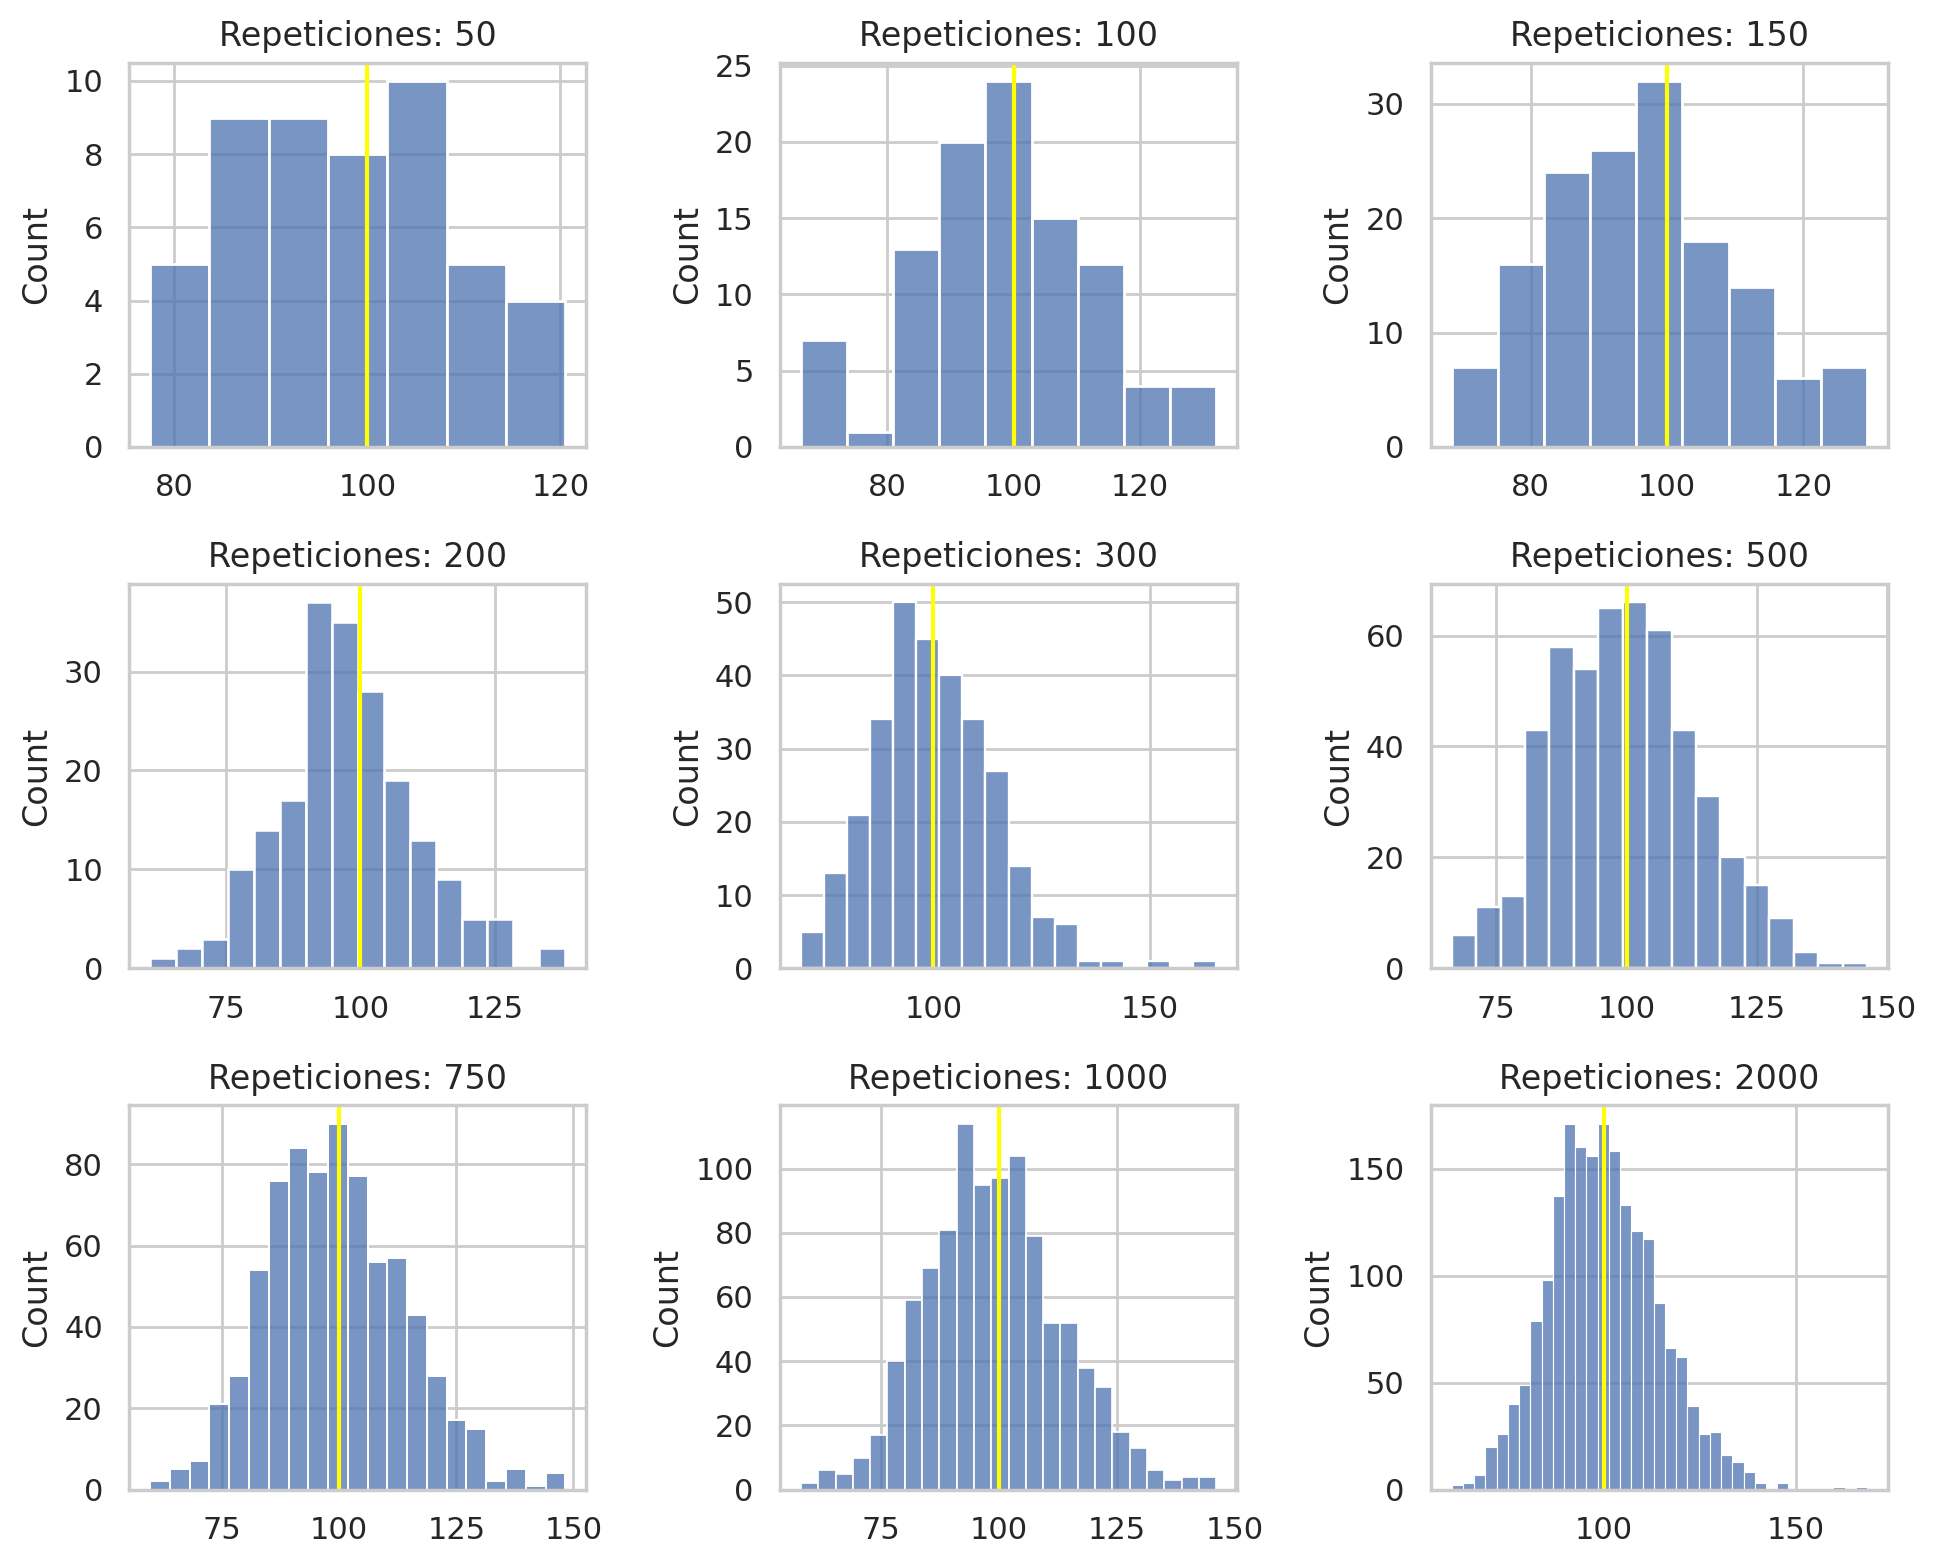

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [50, 100, 150, 200, 300, 500, 750, 1000, 2000]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  # vector de variaza muestrales
  varianzas = []
  rep = 0
  while rep < repeticiones[i]:
    muestra = population.altura.sample(n, replace=True)
    varianzas.append(muestra.var())
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=varianzas)
  g.set_title(f"Repeticiones: {repeticiones[i]}")
  g.axvline(100, color ="yellow") # varianza poblacional
# Ajustamos los gráficos
plt.tight_layout()

### <font color='steelblue'> Proporción muestral

Dada una población de sujetos sobre la que se desea estudiar una característica de interés de tipo discreto, registrada con valores 0 y 1, donde el 1 indica que se cumple cierta condición, surge el parámetro poblacional $\theta$ que refleja la proporción de ocurrencias y que se puede modelizar como:

$$X \sim Bernouilli(\theta)$$

Si extraemos una muestra $X_1, X_2,...,X_n$ de dicha población, la media muestral de eso valores representa el estimador de $\theta$, que denotmaos por $\hat{\theta}$ y cuya distribución en el muestreo viene dada por:

$$\hat{\theta} \sim N\left(\theta, \sqrt{\frac{\theta(1-\theta)}{n}} \right)$$

Para mostrar el comportamiento de la distribución en este caso vamos a generar una población Bernouilli (con ceros y unos), de donde iremos extrayendo muestras de diferentes tamaños y sobre las que evaluaremos la proporción de éxito. En concreto vamos a generar una población de tamaño 1000000 con probabildiad de éxito 0.35.

Generamos la población

In [ ]:
# Generamos los valores de la población
population = pd.DataFrame({"exito": stats.bernoulli.rvs(size=1000000, p=0.35)})

Realizamos ahora el estudio de los diferentes tamaños de la repetición con tamaño muestral de 100. En este caso en los título vamso a mostrar el número de repeticiones, el valor medio y desviación tipca de los valores de las repeticiones.

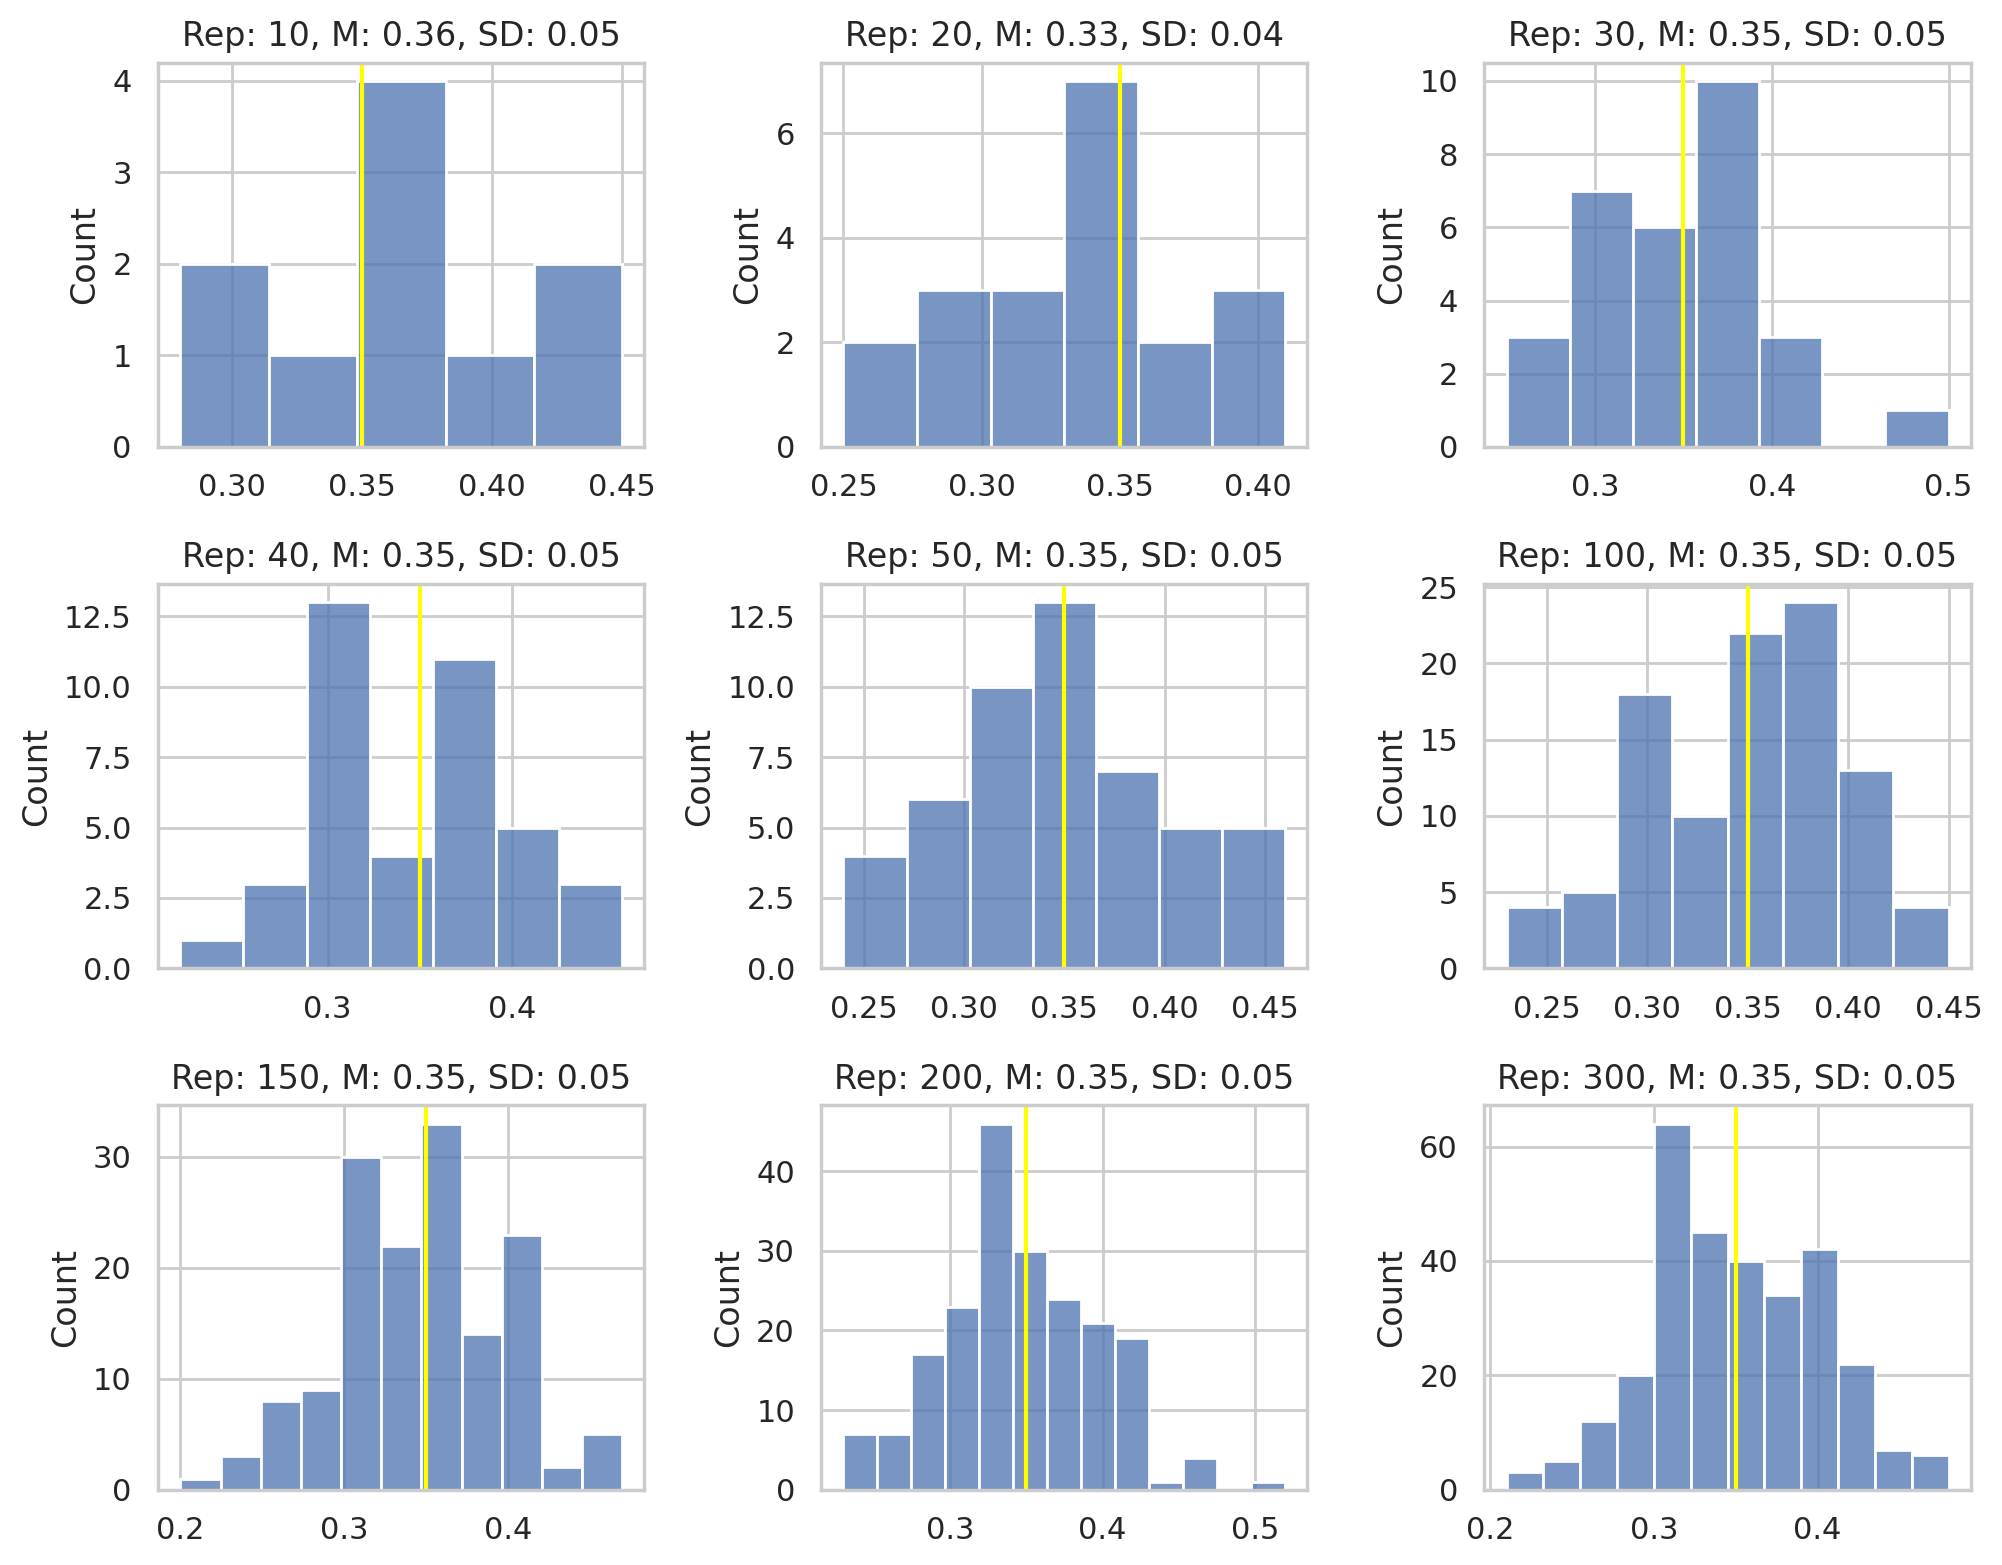

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  propo = []
  rep = 0
  while rep < repeticiones[i]:
    muestra = population.exito.sample(n, replace=True)
    propo.append(muestra.mean())
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=propo)
  g.set_title(f"Rep: {repeticiones[i]}, M: {round(np.mean(propo),2)}, SD: {round(np.std(propo),2)}")
  g.axvline(0.35, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

Conforme aumentamos el número de repeticiones la distribibución se va pareciendo más a la normal centrada en el valor de 0.35. Podemos ver como casi inmediatamente nos acercamos al valor de la proporción de éxito de la oblación con una desviación que se mantiene casi constante e igual al valor poblacional:

In [ ]:
round(np.sqrt(0.35*0.65/100),2)

0.05

### <font color='steelblue'> Diferencia de dos proporciones  muestrales

Cuando estamos interesados en comparar el comportamiento de dos poblaciones, es muy habitual utilizar la diferencia de los parámetros que caracterizan dichas distribuciones apra poder establecer diferencias entre ellas. En este caso comenzamos analizando el caso más sencillo de la comparación de dos porporciones poblacionales.

Dadas dos poblaciones independentes de sujetos sobre los que se desea estudiar unamisma característica de interés de tipo discreto (registrada con valores 0 y 1):

$$X_1 \sim Bernouilli(\theta_1), X_2 \sim Bernouilli(\theta_2)$$

donde $\theta_1$ y $\theta_2$ son las probabilidades de éxito en ambas poblaciones. Si consideramos $\hat{\theta_1}$ y $\hat{\theta_2}$ como las proporciones muestrales obtenidas para muestras de tamaño $n_1$ y $n_2$ para cada población respectivamente entonces:

$$\hat{\theta_1} \sim N\left(\theta_1, \sqrt{\frac{\theta_1(1-\theta_1)}{n_1}}\right), \hat{\theta_2} \sim N\left(\theta_2, \sqrt{\frac{\theta_2(1-\theta_2)}{n_2}}\right)$$

Haciendo uso de las propiedades de la distribución Normal, la distribución en el muestreo para la diferencia de proporciones vendrá aproximada por:

$$\hat{\theta_1} - \hat{\theta_2} \sim N\left(\theta_1-\theta_2, \sqrt{\frac{\theta_1(1-\theta_1)}{n_1} + \frac{\theta_2(1-\theta_2)}{n_2}}\right)$$


A continuación vamos a realizar un estudio numérico para verificar esta distribución. En este caso consideramos dos poblaciones con probabilidades de éxito 0.65 y 0.35 respectivamente pero fijando el mismo tamaño de muestra $(n=50)$. Utilizamos el mismo patrón de repeticiones que en el caso anterior. En primer luagr generamos ambas poblaciones:

In [ ]:
# Generamos ambas pobalciones
pop1 = pd.DataFrame({"exito": stats.bernoulli.rvs(size=1000000, p=0.65)})
pop2 = pd.DataFrame({"exito": stats.bernoulli.rvs(size=1000000, p=0.35)})

Dentro de cada población extaremos la muestra correspondiente, calculamos la proporción de éxito y calculamos la diferencia.

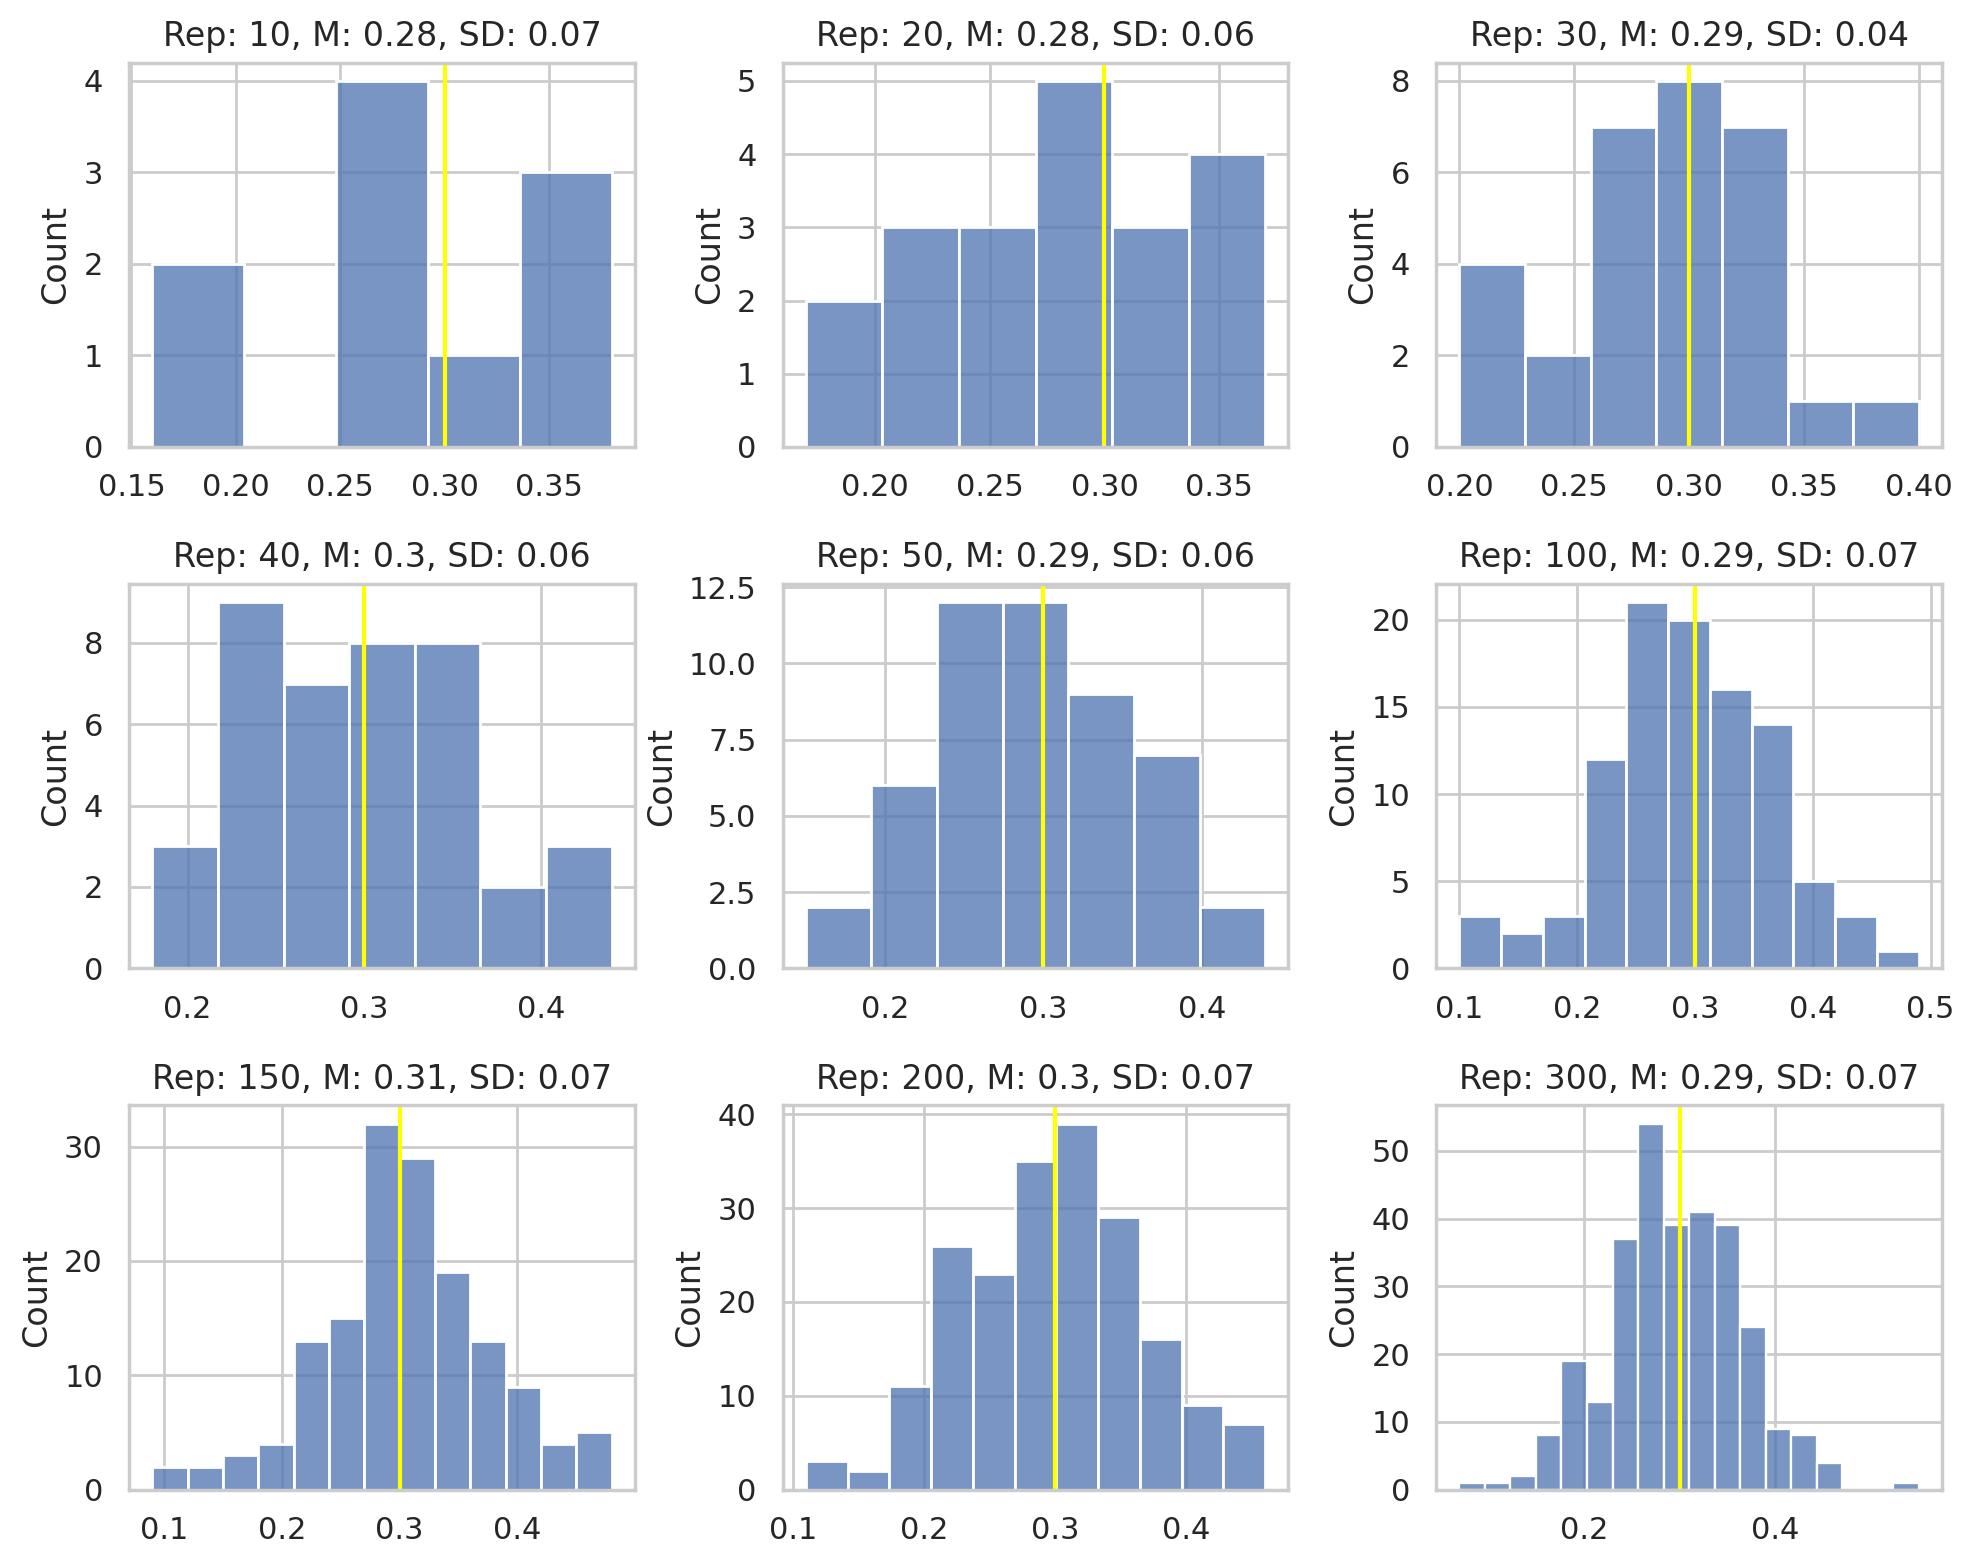

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  propodif = []
  rep = 0
  while rep < repeticiones[i]:
    muestra1 = pop1.exito.sample(n, replace=True)
    prop1 = muestra1.mean()
    muestra2 = pop2.exito.sample(n, replace=True)
    prop2 = muestra2.mean()
    propodif.append(prop1-prop2)
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=propodif)
  g.set_title(f"Rep: {repeticiones[i]}, D: {round(np.mean(propodif),2)}, SD: {round(np.std(propodif),2)}")
  g.axvline(0.30, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

Al ir creciendo el núemro de repeticiones la distribución de la diferencia se parece más a una distribución Nomral centrada en el valor de la diferencia de proporcione poblacionales (0.3). Podemos ver además como la estimación de la diferencia se corresponde con la diferencia pobalcional y la desviación típica se aprece la valor pobalcional

In [ ]:
round(np.sqrt(0.65*(0.35)/100 + 0.35*(0.65)/100),2)

0.07

Veamos que ocurre si consideramos tamaños muestrales diferentes. En este caso consideramos una tamaño de 50 para la pobalción 1, y de 30 para la población 2.

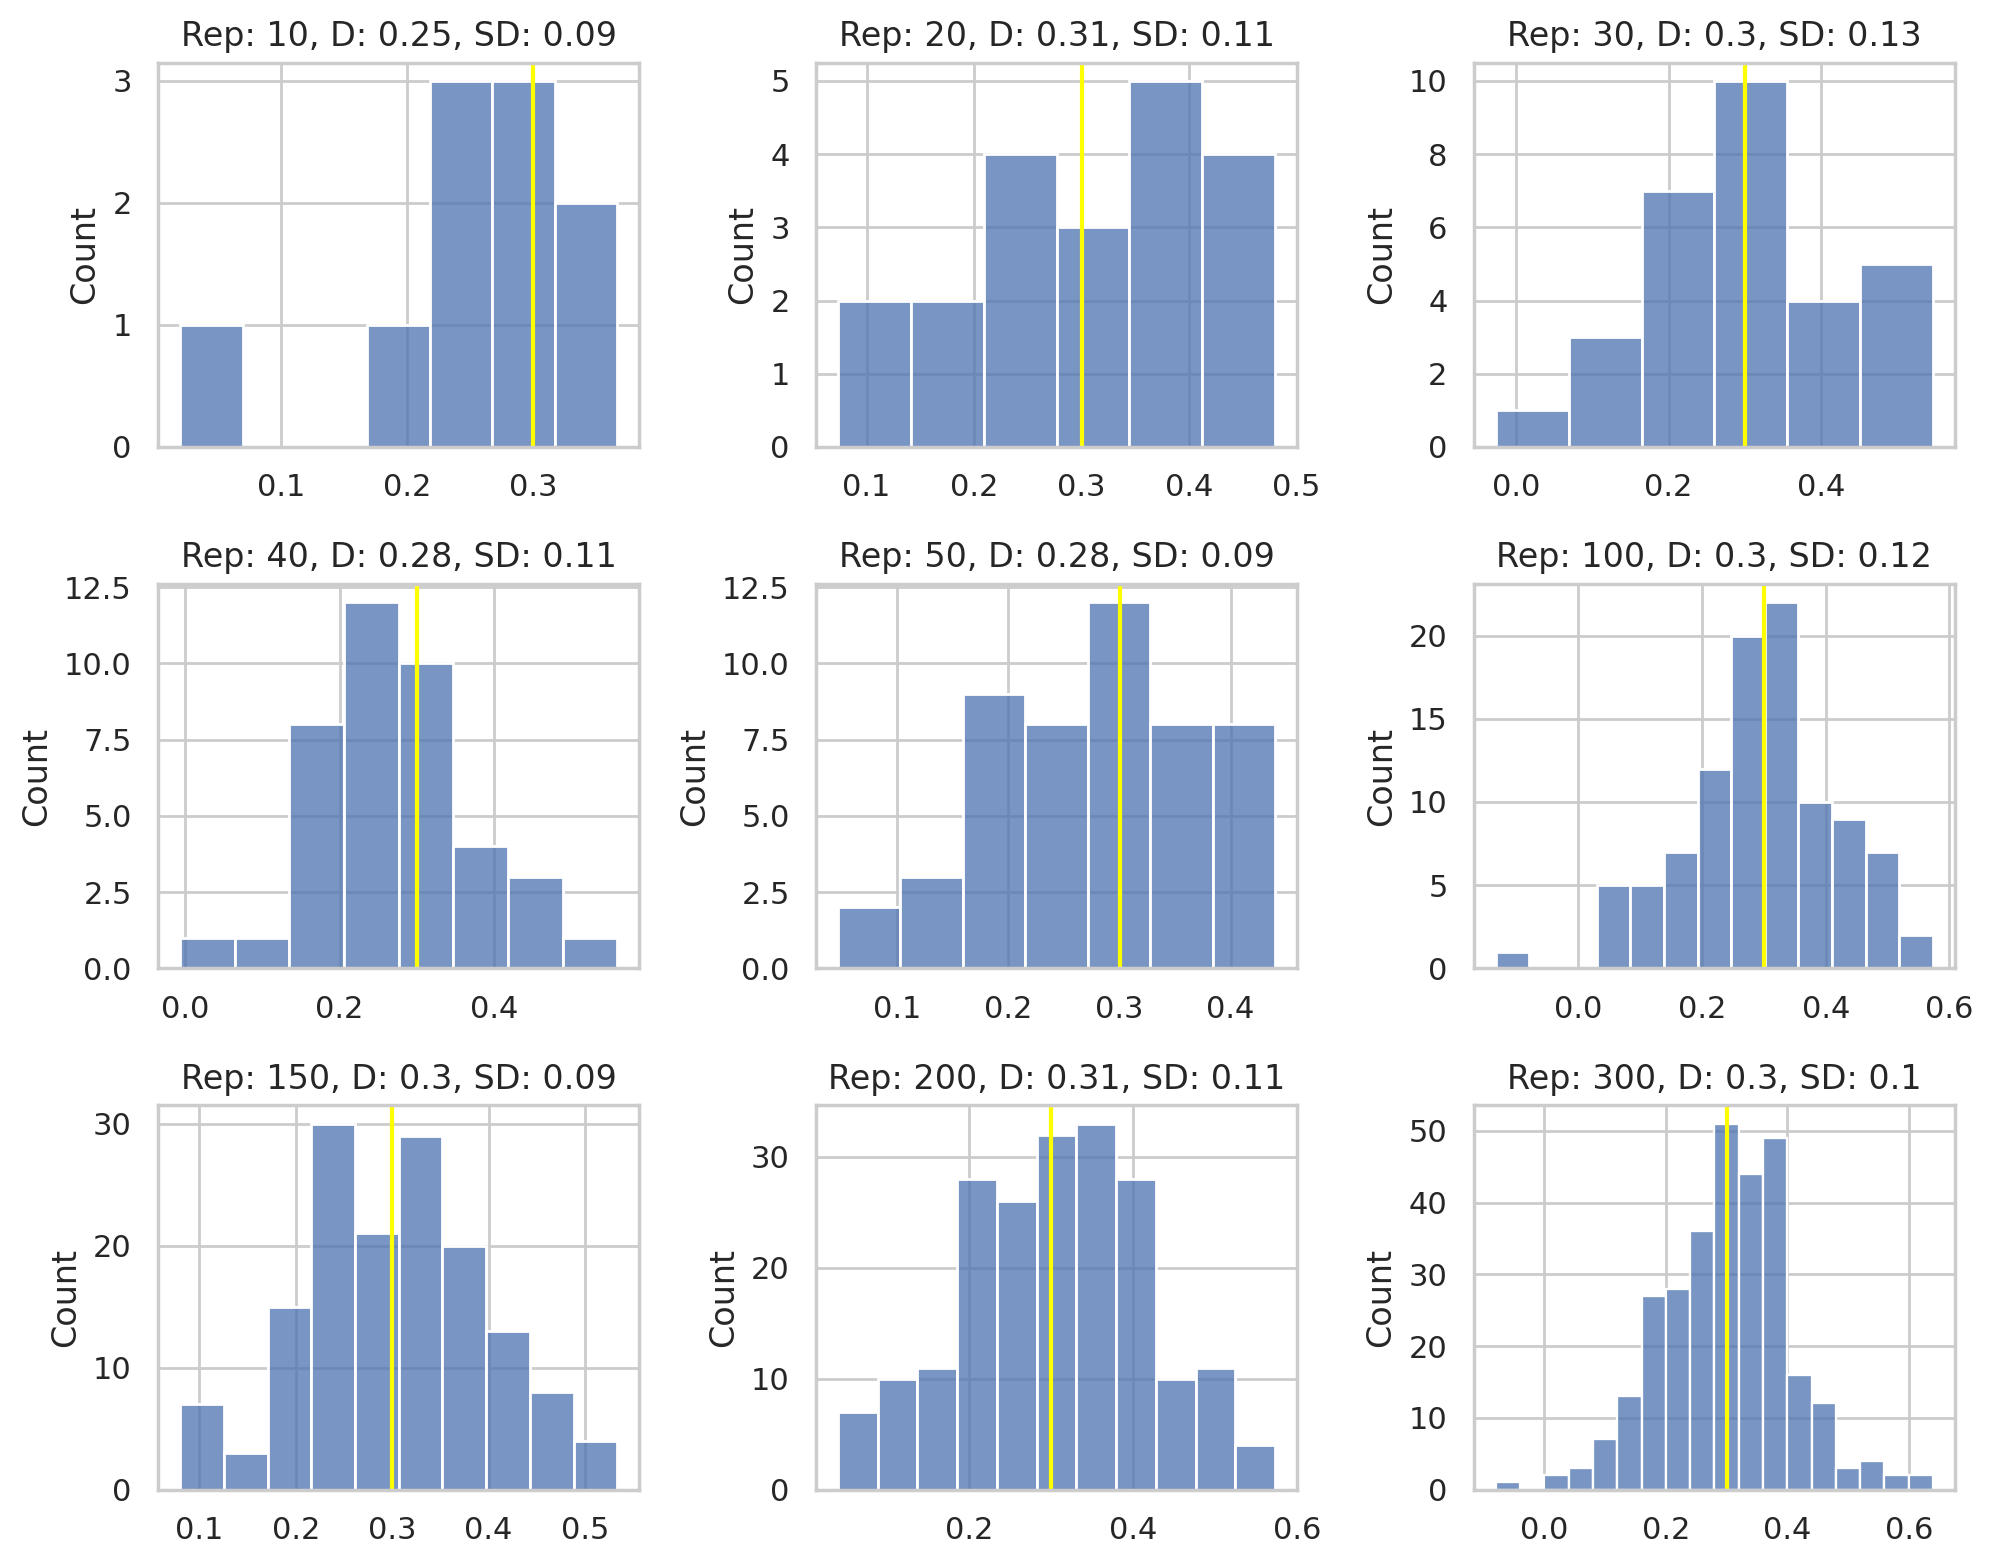

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n1 = 50
n2 = 30
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  propodif = []
  rep = 0
  while rep < repeticiones[i]:
    muestra1 = pop1.exito.sample(n1, replace=True)
    prop1 = muestra1.mean()
    muestra2 = pop2.exito.sample(n2, replace=True)
    prop2 = muestra2.mean()
    propodif.append(prop1-prop2)
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=propodif)
  g.set_title(f"Rep: {repeticiones[i]}, D: {round(np.mean(propodif),2)}, SD: {round(np.std(propodif),2)}")
  g.axvline(0.30, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

En este caso la esimación de la diferencia se sítua en 0.3 mientras que la desviación típica es

In [ ]:
round(np.sqrt(0.65*(0.35)/50 + 0.35*(0.65)/30),2)

0.11

El análisis numérico muestra la convergencia a la distribución en el muestreo propuesta.

### <font color='steelblue'> Diferencia de dos medias  muestrales

En este caso consideramos dos poblaciones Normales

$$X_1 \sim N(\mu_1,\sigma_1), X_2 \sim N(\mu_2,\sigma^2)$$

y estamos interesados la distribución en el muestreo de $\bar{X_1} - \bar{X_2}$, sabiendo que:

$$\bar{X_1} \sim N\left(\mu_1,\frac{\sigma_1}{\sqrt{n_1}}\right), \bar{X_2} \sim N\left(\mu_2,\frac{\sigma_2}{\sqrt{n_2}}\right)$$

Haciendo uso de las propiedades de la distribución Normal tenemos que:

$$\bar{X_1} - \bar{X_2} \sim N\left(\mu_1-\mu_2, \frac{\sigma_1}{\sqrt{n_1}} + \frac{\sigma_2}{\sqrt{n_2}}\right)$$

Para el estudio numérico consideramos una media de 10 con una desviación típica de 10 para la primera población, y media de 2 y desviación típica de 10 para la segunda. En primer lugar consideramos los tamaños muestrales iguales a 30 para ambas poblaciones. Generamos las poblaciones:

In [ ]:
# Generamos los valores de la población
pop1 = pd.DataFrame({"altura": stats.norm.rvs(size=1000000, loc=10, scale=10)})
pop2 = pd.DataFrame({"altura": stats.norm.rvs(size=1000000, loc=2, scale=10)})

Generamos el estudio numérico

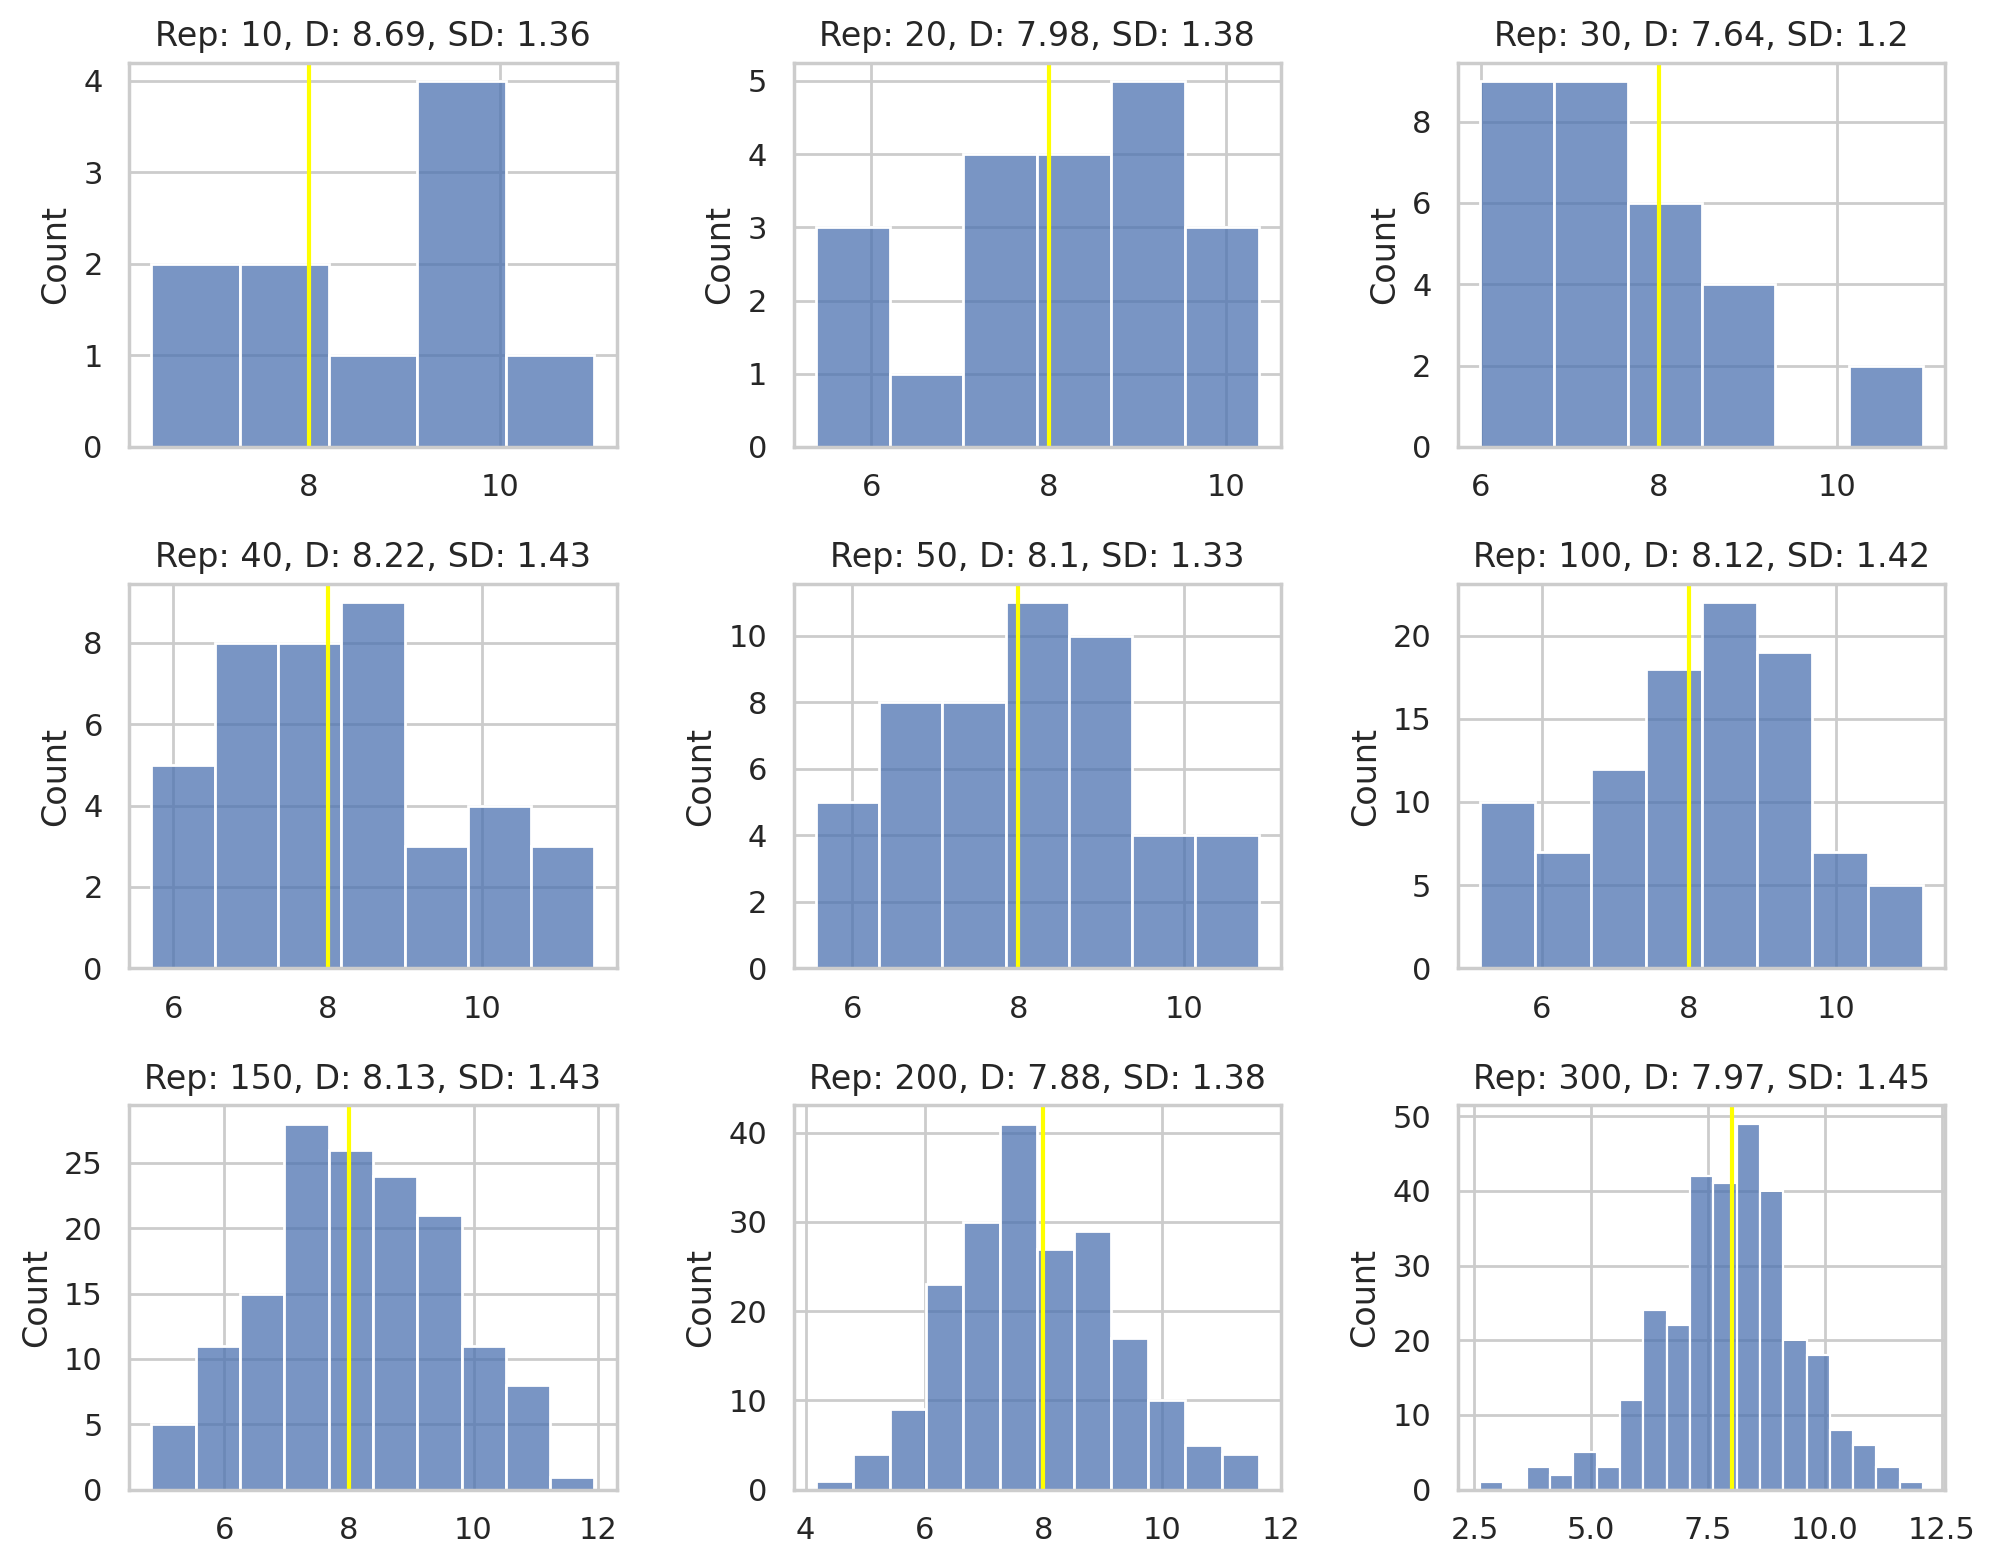

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  meandif = []
  rep = 0
  while rep < repeticiones[i]:
    muestra1 = pop1.altura.sample(n, replace=True)
    m1 = muestra1.mean()
    muestra2 = pop2.altura.sample(n, replace=True)
    m2 = muestra2.mean()
    meandif.append(m1-m2)
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=meandif)
  g.set_title(f"Rep: {repeticiones[i]}, D: {round(np.mean(meandif),2)}, SD: {round(np.std(meandif),2)}")
  g.axvline(8, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

Podemos ver como la distribución obtenida se centra en la diferencia poblacional, mientras que la desviación típica viene dada por

In [ ]:
round(10/np.sqrt(100) + 10/np.sqrt(100),3)

2.0

En este caso podemos ver que la deviación típica de las diferencias no se aproxima tab rapidamente. Posteriormente veremos como debemos modificar la distribución en el muestro para la diferencia de medias muestrales para que la aproximación sea más precisa.

### <font color='steelblue'> Cociente de dos varianzas  muestrales

Cuando queremos comparar dos varibilidades pobalciones no podemos usar la diferencia debido a que podríamos obtener valores negativos, mientras que las variabilidades simepre son positivas. Por este motivo consideramos el cociente entre las variabilidades, asimuendo siempre que la mayor se sitúa en el numerador, para compararlas. De esta forma un valor próximo a 1 indica que mabas varibilidades son iguales.

En este caso consideramos dos poblaciones Normales

$$X_1 \sim N(\mu_1,\sigma_1), X_2 \sim N(\mu_2,\sigma^2)$$


donde

$$\frac{(n_1-1)S^2_1}{\sigma^2_1} \sim \chi^2_{n_1-1}, \frac{(n_2-1)S_2^2}{\sigma^2_2} \sim \chi^2_{n_2-1}$$

y estamos interesados la distribución en el muestreo de $$\frac{S^2_1}{S^2_2}$$

Haciendo uso de las propiedades de la distribución Chi-cuadrado tenemos que:

$$\frac{S^2_1}{S^2_2} \sim F_{n_1-1,n_2-1}$$

se distribuye mediante una distribución F de Snedecor con $n_1-1$ y $n_2-1$ grados de libertad respectivamente.

Para el estudio numérico utilizamos las poblaciones definidas en el punto anterior.

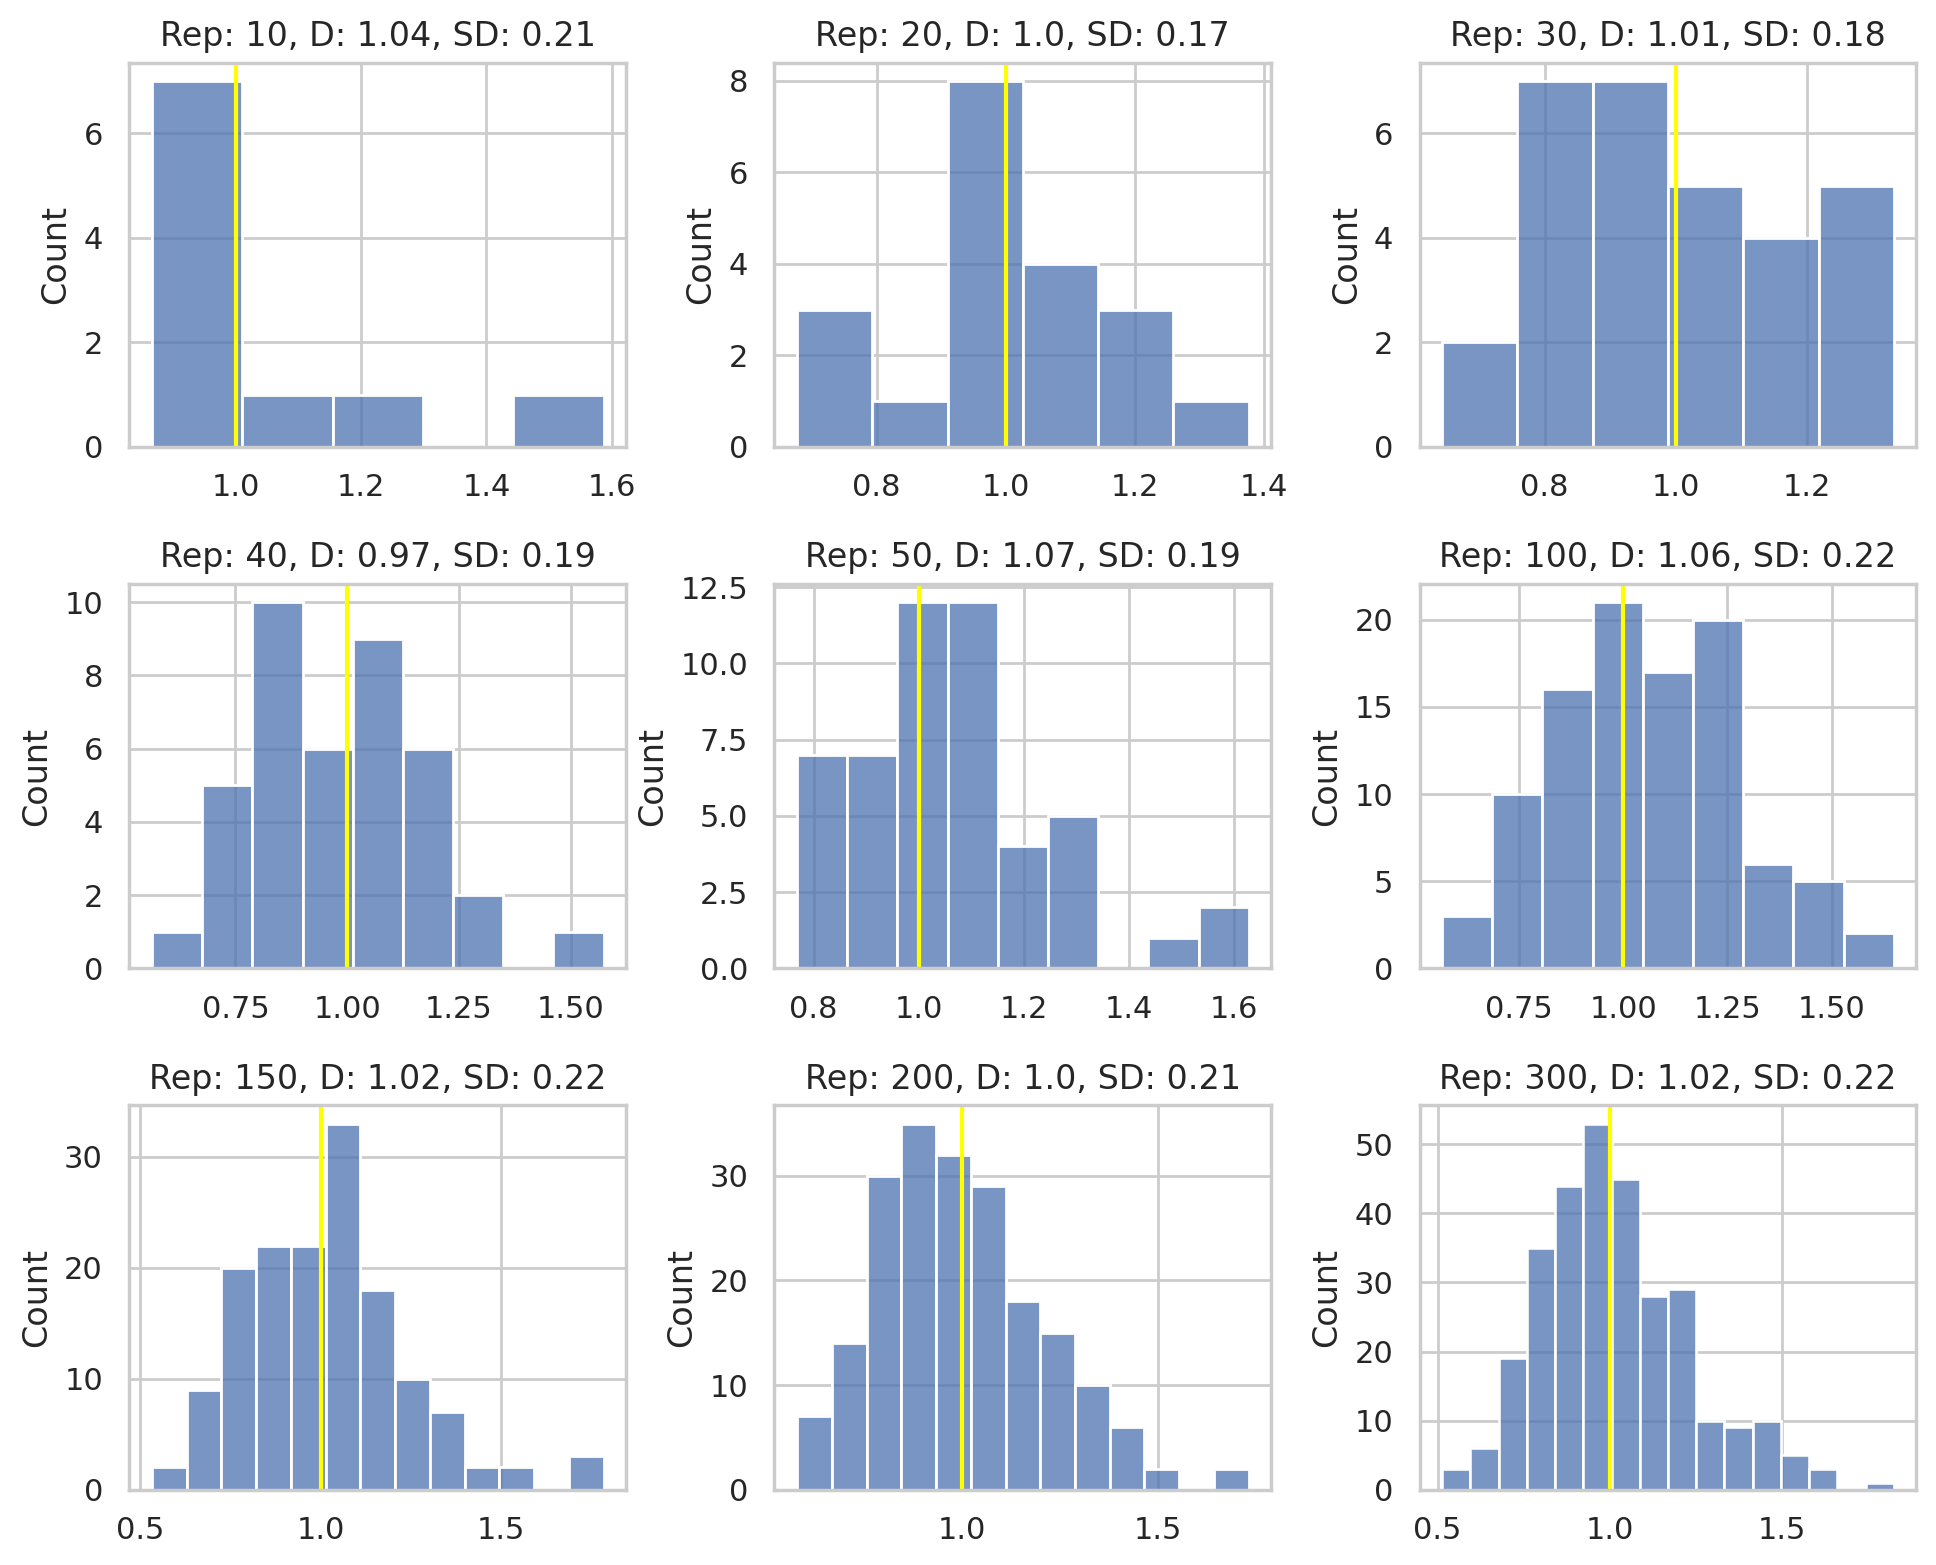

In [ ]:
# fijamos el número de muestras que vamos a extraer así como su tamaño
repeticiones = [10, 20, 30, 40, 50, 100, 150, 200, 300]
n = 100
# Grafico
fig = plt.figure(figsize=(10, 8))
# primer subgráfico
for i in range(len(repeticiones)):
  varcoc = []
  rep = 0
  while rep < repeticiones[i]:
    muestra1 = pop1.altura.sample(n, replace=True)
    m1 = muestra1.var()
    muestra2 = pop2.altura.sample(n, replace=True)
    m2 = muestra2.var()
    varcoc.append(m1/m2)
    rep += 1
  plt.subplot(3,3,i+1)
  g=sns.histplot(data=varcoc)
  g.set_title(f"Rep: {repeticiones[i]}, D: {round(np.mean(varcoc),2)}, SD: {round(np.std(varcoc),2)}")
  g.axvline(1, color ="yellow")
# Ajustamos los gráficos
plt.tight_layout()

## <font color='steelblue'> 4. Procedimientos de inferencia estadística

En este punto se presentan los aspectos generales de los procesos de inferencia que utilizaremos en cuadernos sucesivos. Los prcedimiento que consideramos son la estimación puntual, estimación por intervalos de confiaza, y constraste de hipótesis.

### <font color='steelblue'> Estimación puntual

El procedimiento de inferencia estadística más sencillo es la estimación puntual de un parámetro $\eta$, que se denota por $\hat{\eta}$ , en la que se calcula un único valor con los datos muestrales para estimar el parámetro de la población que desconocemos.

De forma natural, los estimadores puntuales en las situaciones inferenciales más sencillas corresponden  con los valores muestrales que juegan un papel similar en la población. En el caso de estar interesados en el parámetro de una población obtenemos la tabla de estimadores puntuales siguiente:

| Parámetro poblacional| Estiamdor puntual|
|------|------|
|Media poblacional ($\mu$)| Media muestral ($\hat{\mu} = \bar{x}$)|
|Varianza poblacional ($\sigma^2$)| Varianza muestral ($\hat{\sigma}^2 = s^2$)|
|Desviación típica poblacional ($\sigma$)| Desviación típica muestral ($\hat{\sigma} = s$)|
|Proporción poblacional ($\theta$)| Proporción muestral ($\hat{\theta} = \hat{\theta}$)|

Imaginemos que en lugar de tener una única población estamos interesados en relacionar un mismo parámetro poblacional en dos poblaciones distintas. Por ejemplo, estamos interesados en ver si la media de cierta característica tiene el mismo o valor o diferentes en dos poblaciones distintas. En este situación tendríamos una media $\mu_1$ para la población 1, una media $\mu_2$ para la población 2, y estamos interesados en conocer cuanto se parecen ambas medias. La forma de proceder es construir un único parámetro que relaciona los parámetros de amabas poblaciones y que nos permitirá concluir sobre cuanto se parecen las dos poblaciones. El parámetro utilizado habitualmente es la diferencia entre las medias de las dos poblaciones, ya que cuando ambas medias se parecen el valor de la diferencia estará próximo a cero, mientras que si no se parecen la diferencia se alejará del valor de cero. En el caso de als varainzaz como ya hemos comentado antes utilizamos el cociente.

Tendríamos entonces:

| Parámetros poblacionales| Parámetro conjunto|Estimador puntual|
|------|:------:|:------:|
|Dos medias ($\mu_1, \mu_2$) | $\mu_1 - \mu_2$ | $\bar{x}_1 - \bar{x}_2$|
|Dos proporciones ($\theta_1, \theta_2$) | $\theta_1 - \theta_2$ | $\hat{\theta}_1 - \hat{\theta}_2$|
|Dos varianzas ($\sigma_1^2, \sigma_2^2$) | $\sigma_1^2/ \sigma_2^2$ | $s^2_1/s^2_2$|

Podemos ver que para poder construir un estimador puntual conjunto únicamente necesitamos los estimadores puntuales asociados a los parámetros de cada población.

El problema principal es que debido a que la muestra suele tener un tamaño bastante reducido en comparación con el tamaño de la población, siempre existe un error asociado al proceso de estimación del parámetro de interés, que puede llegar a ser crítico en algunas situaciones prácticas. Esto implica que para diferentes muestras tendremos diferentes estimadores puntuales, pero dado que cuando trabajamos con datos reales solo dispondremos de una muestra, y se hace necesario establecer una medida del error de la estimación obtenida.


### <font color='steelblue'> Estimación por intervalos de confianza

Como hemos visto anteriormente, la estimación puntual no proporciona una medida del error que se comete con dicho procedimiento de estimación por lo que no resultan de gran utilidad por sí solos. Por ese motivo se introducen los intervalos de confianza que además de proporcionar un estimador puntual, establecen una medida del error cometido y del grado de confianza que debe poseer el intervalo obtenido.

El procedimiento de estimación por intervalos de confianza trata de proporcionar un rango o intervalo de valores de confianza:

$$[\eta_l, \eta_u]$$

para el parámetro de interés ($\eta$), en función de las estimación puntual y de una medida del error cometida con dicho estimador que tiene en cuenta su comportamiento (distribución en el muestreo).

Para su construcción se ha de tener en cuenta:

* **Tamaño de la muestra**. Cuanto mayor es el tamaño de la muestra obtenida sabemos que el estimador puntual utilizado estará más cerca del verdadero valor del parámetro, y por tanto menor será el error que se comete.

* **Variabilidad del estadístico** utilizado en la estimación puntual. Cuanto mayor sea la variabilidad del estadístico utilizado en el proceso de estimación puntual, mayor será el error cometido.  Dicha variabilidad se puede establecer si se conoce la distribución en el muestreo del estadístico, ya que vendrá dada por su desviación típica.

* **Nivel de confianza** que se desea para el intervalo construido. El nivel de confianza establecido para el intervalo de estimación deseado provoca que cuanto mayor sea el nivel deseado, más amplio será dicho intervalo y por lo tanto menos precisión en la estimación. Esto resulta obvio ya que si queremos estar seguros del rango de valores posibles para el parámetro de interés lo más fácil resulta tomar la mayor cantidad de ellos.

El nivel de confianza con el que acotaremos representa el porcentaje de intervalos que, tomados de $100$ muestras independientes distintas, contienen en realidad el valor desconocido y se expresa como $1 - \alpha$. Por contra, el **error aleatorio** o **nivel de significancia** será el número de intervalos, sobre los $100$ tomados, que no contienen el valor buscado y se expresa como $\alpha$. El *nivel de confianza* con el que trabajemos y la amplitud del *intervalo de confianza* serán directamente proporcionales, es decir, un intervalo es más amplio implicará un mayor nivel de confianza, mientras que si el intervalo es más pequeño (estimación más precisa) su confianza será menor. La relación entre los *intervalos de confianza* y los *niveles de significación* son inversamente proporcionales.

El *nivel de confianza* que se suele utilizar es el del $95\%$, es decir, si tomamos $100$ muestras independientes distintas, $95$ veces obtendremos un intervalo de confianza que contenga el valor real (poblacional).


Al rango de valores contenidos entre $\eta_l$ y $\eta_u$ se le denomina intervalo de confianza al $100(1-\alpha)%$, y valores habituales del porcentaje de confianza son el 80%, 90%, 95% y 99%, que corresponden con los valores de  iguales a 0.2, 0.1, 0.05, y 0.01 respectivamente. Todos los intervalos de confianza siguen la misma fórmula:

$$
IC = \hat{\theta} \pm valor~crítico~*~error~muestral
$$

$\hat{\theta}$ es la estimación muestral correspondiente, el valor crítico dependerá de la distribución probabilística que siga dicho parámetro, aunque la gran mayoría de veces seguirá una *normal* o una *t de Student*, y el error muestral será diferente para cada parámetro.



### <font color='steelblue'> Contraste de hipótesis

Pasaremos ahora a ver la otra parte de la *inferencia estadística*: el **contraste de hipótesis**. Esta nos ayudará a determinar si nuestra estimación puntual o la acotación (intervalo de confianza) del parámetro poblacional es aceptable o no. Consistirá en una prueba estadística, con una significación (porcentaje de error, $\alpha$), para decidir si una proposición que hagamos sobre la población (estimación o acotación) será válida o no. La proposición es el nombre que se le da a la *hipótesis estadística* y es la que aceptaremos o rechazaremos, que nos servirá para ver si los datos extraídos de la muestra son compatibles o no con los que hay en la población.

La **hipótesis estadística** es una propuesta que se hace acerca de la función de probabilidad o de la función de densidad de una o varias variables aleatorias. Esta propuesta deberá estar referida a la forma que tiene la distribución de probabilidad, el valor del parámetro que lo defina o bien a ambos. Es, por tanto, una afirmación acerca de la distribución que sigue la población.

El *contraste de hipótesis* que vayamos a generar estará basado en la información que nos proporcione la muestra que extraigamos de la población. Por lo que, si rechazamos la *hipótesis*, estaremos indicando que los datos ofrecidos por la muestra tienen una cierta evidencia de falsedad. La forma de plantear la *hipótesis nula* nos permitirá tener un modelo probabilístico que nos ayudará a llegar a la decisión final.

En el caso más sencillo, imaginemos que tenemos un parámetro poblacional $\theta$ que puede tomar valores en el conjunto $\Theta$. El procedimiento de contraste se basa en definir dos subconjuntos disjuntos en $\Theta$, con el fin de descubrir en cuál de ellos es más plausible que se encuentre $\theta$.

Estos subconjuntos disjuntos se denominan hipótesis. El procedimiento genérico establece dos hipótesis:

* **Hipótesis nula**, que se denota por $H_0$, y que generalmente expresa el valor o conjunto de valores del parámetro, $\Theta_0$, que indican que no hay diferencia con respecto al verdadero valor del parámetro.
* **Hipótesis alternativa**, que se denota por $H_a$, y que generalmente expresa el valor o conjunto de valores complementarios, $\Theta_1$ , a los dados en la hipótesis nula.

Formalmente, el problema de contraste de hipótesis se plantea como:


$$\left\lbrace\begin{array}{l}
H_0: \theta \in \Theta_0\\
H_a: \theta \in \Theta_1
\end{array}\right.$$

Con el planteamiento de estas hipótesis, dividimos los resultados muestrales en 2 zonas: *zona de rechazo* y *zona de aceptación*. Mostramos a continuación la *zona de no rechazo* y la de *rechazo* para el denomicado *contraste de hipótesis bilateral* (que plantearemos más adelante).

<center><img src=https://raw.githubusercontent.com/ia4legos/Statistics/main/images/img_350_10_10.png width="600" height="425"></center>

* **Zona o región de rechazo:** la zona roja, que está formada por los valores del *estadístico de contraste* (explicaremos a continuación qué es) que nos llevan a rechazar la *hipótesis nula*, los que se alejan mucho de $H_0$. Será poco probable que se den si la *hipótesis nula* es verdadera. Los puntos que delimitan esta región ($-\theta$ y $\theta$) se les conocen como **puntos críticos**, siendo similares a los *valores críticos* que vimos en el cuadernos pasado. También conocemos esta zona como *región crítica*.

* **Zona o región de no rechazo:** en la imagen, es la zona azul. La forman el conjunto de los valores del *estadístico de contraste* que nos lleva a aceptar la *hipótesis nula*. Esta zona también se le puede llamar como *región de no rechazo*.

A continuación presentamos las tres posibilidades más habituales de situaciones de contraste:

* **Contrate Bilateral**, donde se especifica en la hipótesis nula un único valor para el parámetro poblacional, es decir, se desea contratas si el valor del parámetro poblacional es igual a un valor específico $\theta_0$, de forma que el contraste viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \theta = \theta_0\\
H_a: \theta \neq \theta_0
\end{array}\right.$$

* **Contrate unilateral a la izquierda**, donde se especifica en la hipótesis nula que el valor del parámetro poblacional es menor o igual a un valor específico $\theta_0$, de forma que el contraste viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \theta \leq \theta_0\\
H_a: \text{no } H_0
\end{array}\right.$$

* **Contrate unilateral a la derecha**, donde se especifica en la hipótesis nula que el valor del parámetro poblacional es mayor o igual a un valor específico $\theta_0$, de forma que el contraste viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \theta \geq \theta_0\\
H_a: \text{no } H_0
\end{array}\right.$$

Estas hipótesis se deben establecer antes de obtener la información muestral ya que deben reflejar conocimiento previo sobre el parámetro poblacional de interés. La muestra recogida aportará las evidencias suficientes para rechazar o no rechazar la hipótesis nula planteada.

Para poder decidir entre una de las dos hipótesis planteadas en cada uno de los contrastes que hemos presentado debemos seguir el proceso siguiente:

1. Elegir un nivel de significación, $\alpha$, que refleja el riesgo que tomamos cuando rechazamos la hipótesis nula o probabilidad de rechazar la hipótesis nula cuando es cierta, es decir:

$$\alpha = P(\text{Rechazar } H_0 | H_0 \text{ es cierta})$$

2. Establecer estadístico de contraste (EC) que nos permita, utilizando la información muestral, estudiar la compatibilidad de dicha información con la hipótesis nula planteada.

Para decidir sobre el contraste planteado utilizaremos el **p-valor**, que representa la probabilidad de que el valor del $EC$ sea superior al valor observado de dicho estadístico, $EC_{obs}$ ,atendiendo a la distribución en el muestreo, es decir,

$$\text{p-valor}=P(EC \geq EC_{obs})$$

Para tomar una decisión sobre el contraste miramos si el p-valor obtenido y concluimos que:
* Si $p-valor < \alpha$, es decir, la probabilidad observada es inferior a la probabilidad prefijada de rechazar la hipótesis nula cuando es cierta, de forma que, tenemos evidencias estadísticas suficientes para rechazar la hipótesis nula a favor de la hipótesis alternativa.
* Si $p-valor > \alpha$ , es decir, la probabilidad observada es superior a la probabilidad prefijada de rechazar la hipótesis nula cuando es cierta, de forma que, no tenemos evidencias estadísticas suficientes para rechazar la hipótesis nula.

Normalmente se eligen valores pequeños, $\alpha$=0.1, 0.05, y 0.01. Por ejemplo, si tomamos una significación del 5%, tendremos una probabilidad de 0.05 de rechazar la hipótesis nula cuando en realidad es cierta.

A la hora de realizar un *contraste de hipótesis* hay que tener en cuenta que cuando se decide rechazar o no la *hipótesis nula*, es posible que se esté cometiendo un cierto error. Cuando rechazamos $H_0$, estamos diciendo que esta *hipótesis* es nula, y cuando no lo hacemos, significa que es verdadera. Con esto, se consideran dos tipos de errores que se pueden cometer cuando realizamos un *contraste*:

* **Error tipo I** ($\alpha$): es el error que se comete al rechazar la *hipótesis nula*, cuando en realidad es cierta.

* **Error tipo II** ($\beta$): es el error que se comete al no rechazar la *hipótesis nula*, cuando en realidad es falsa.

Mostramos a continuación una tabla sobre los errores que se pueden cometer con respecto a $H_0$, que es la *hipótesis* en la que nos centramos.

$H_0$ | Verdadera | Falsa
:---: | :---: | :---:
**No rechazar** | $(1 - \alpha)$ <br> Decisión correcta | $\beta$ <br> Error tipo $II$
**Rechazar** | $\alpha$ <br> Error tipo $I$ | $(1 - \beta)$ <br> Decisión correcta

Se le conoce como **potencia de un contraste** a la probabilidad que tenemos de no aceptar $H_0$ cuando efectivamente es falsa ($1 - \beta$). Su homólogo para el parámetro $\alpha$ es el **valor de confianza**, que es la probabilidad de aceptar $H_0$ cuando es verdadera ($1 - \alpha$). Mientras tanto, el **nivel de significación** ($\alpha$), nos dice a partir de qué valor estamos cometiendo un error de tipo $I$, es decir, la máxima probabilidad de no aceptar la *hipótesis nula* cuando es cierta. Este nivel se determinará antes de que realicemos el *contraste*, para que no influya en nuestra decisión. Por lo tanto, el *nivel de significación*, $\alpha$, representa el riesgo máximo admisible cuando no aceptamos $H_0$.

Cuando sabemos todo esto sobre los *contrastes de hipótesis*, tan solo nos faltará saber cómo plantearlo para luego aplicar nuestros conocimientos y sacar conclusiones. Estos detalles los analizaremos en los cuadernos siguientes para la inferencia sobre proporciones y medias.